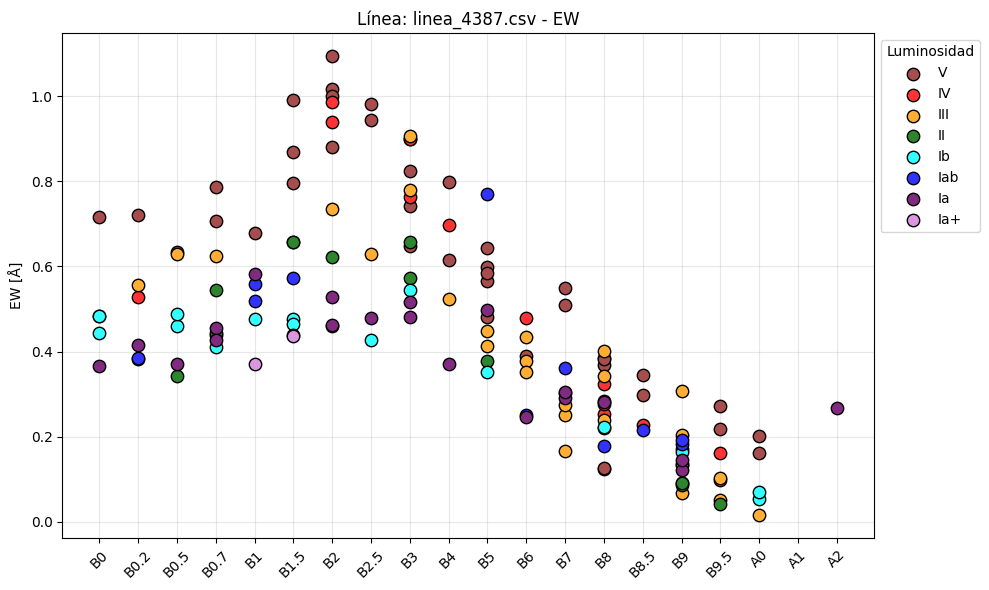

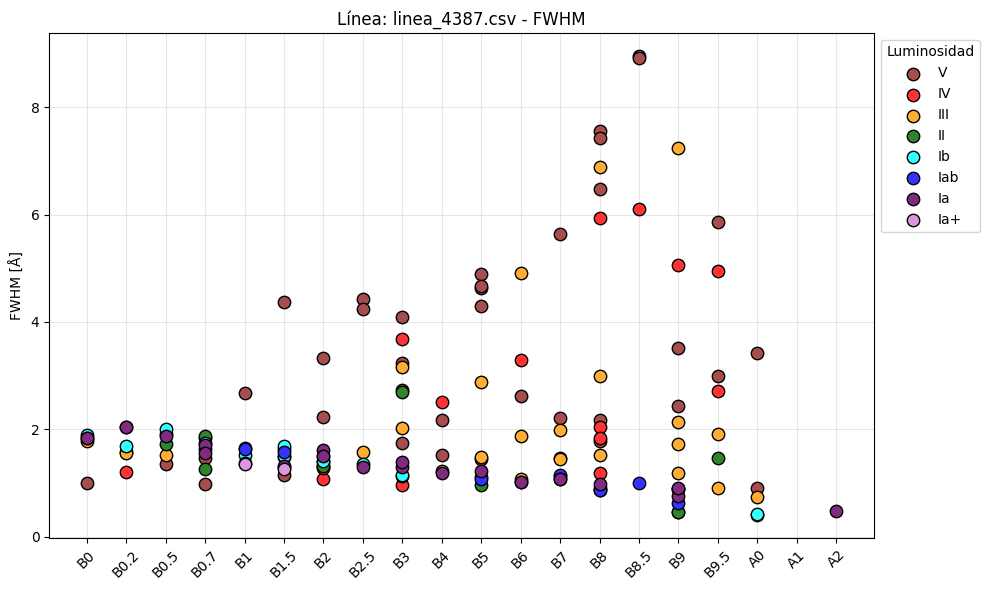

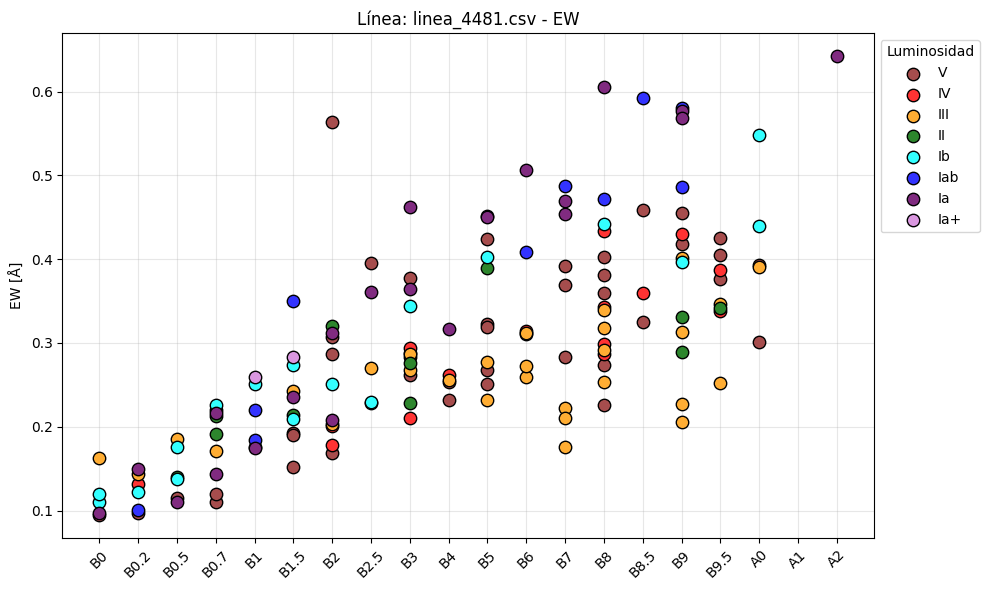

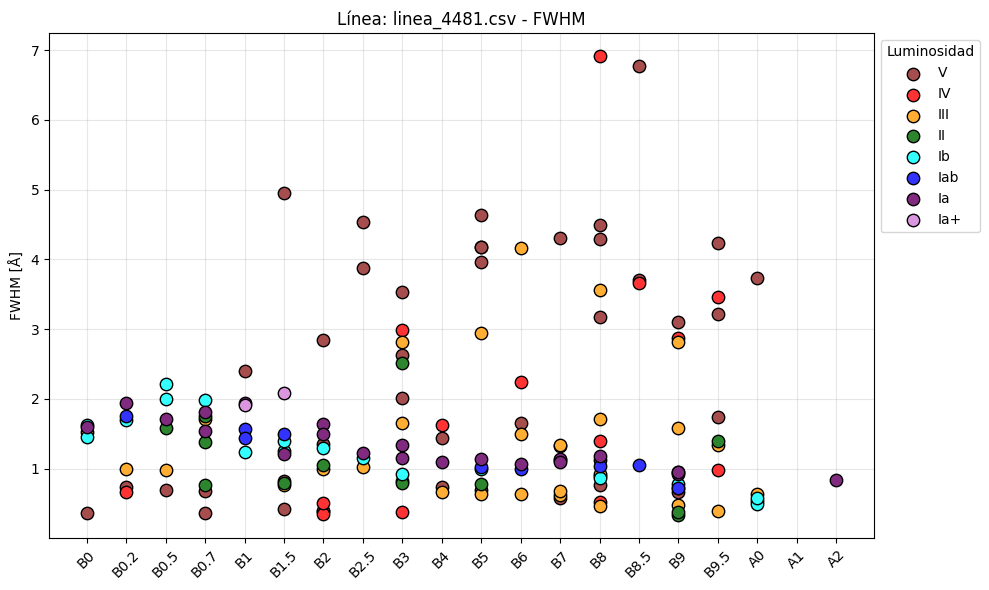

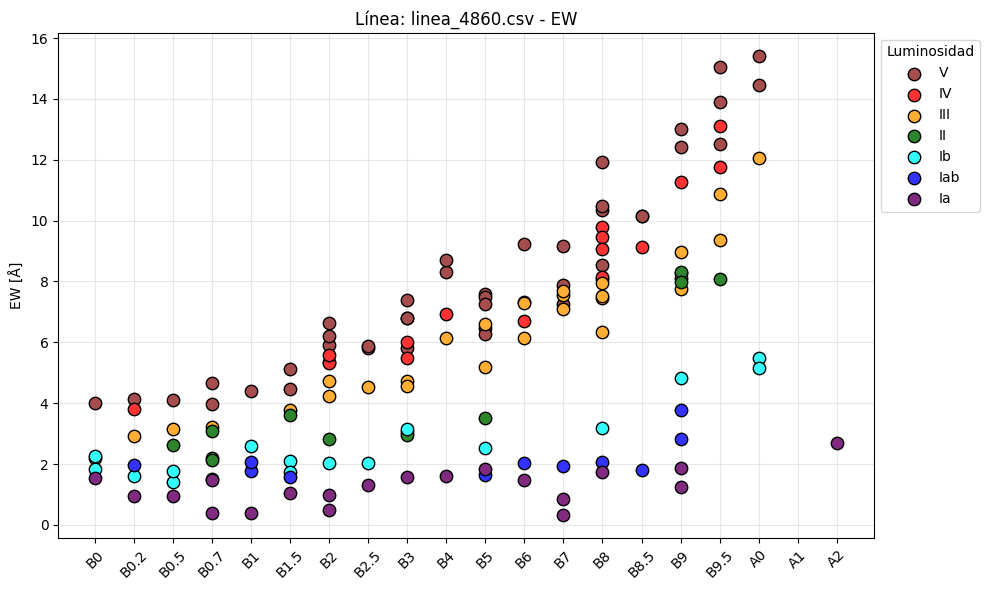

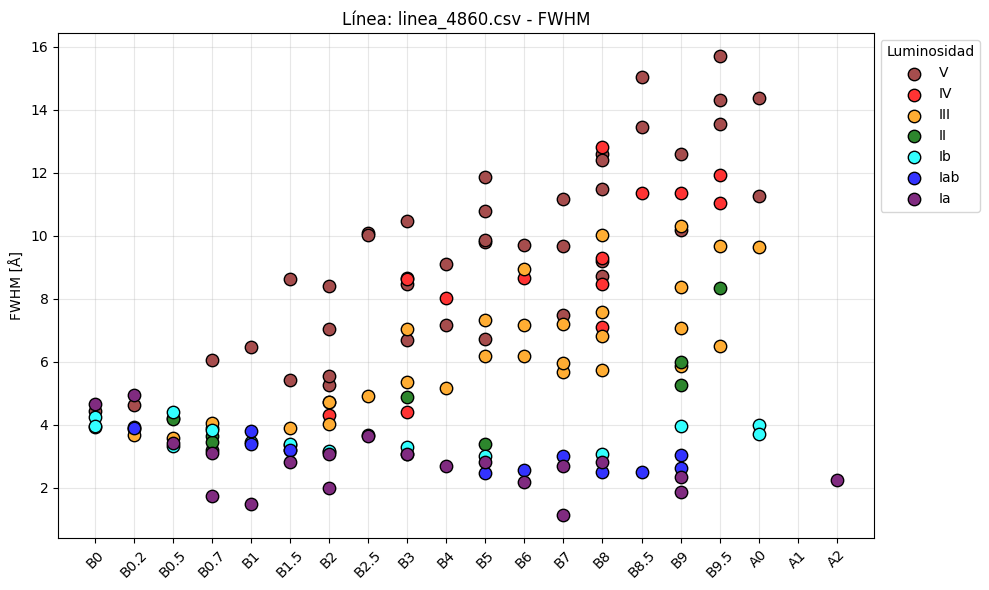

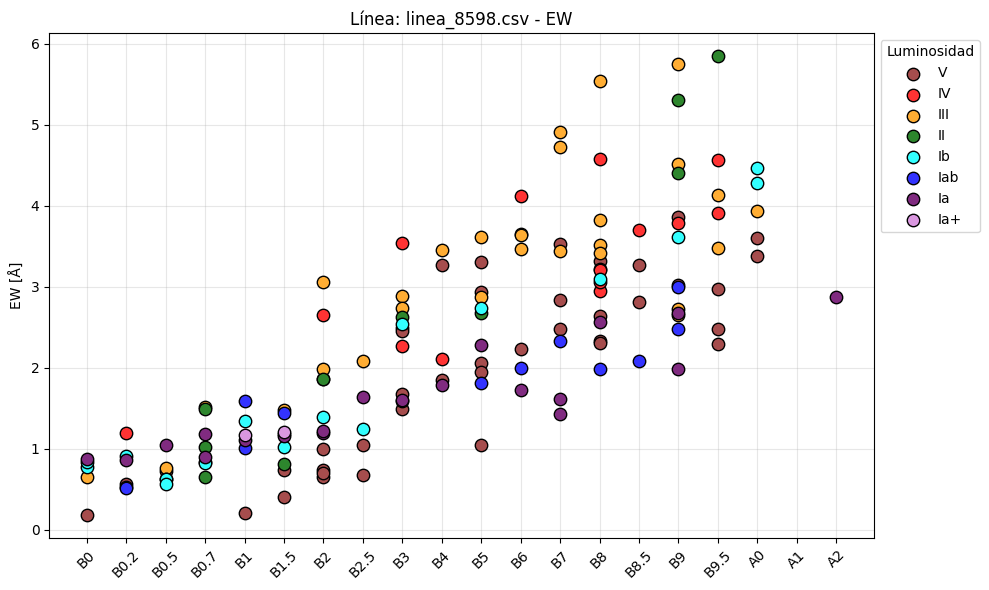

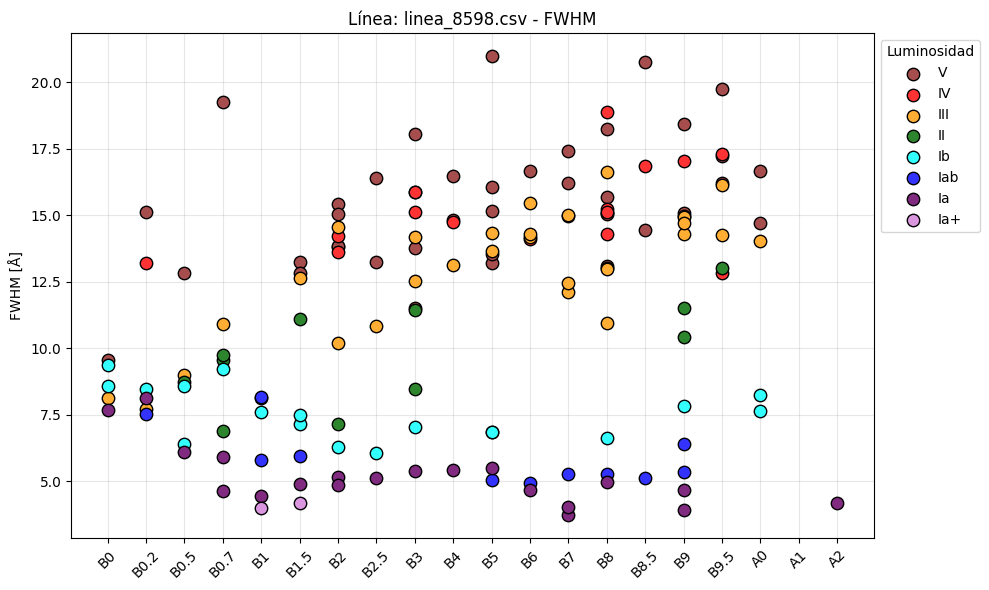

In [46]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# 1. Configuración de rutas
PATH_ANALISIS = r"C:\Users\User\Documents\TFG\Análisis"

# 2. Diccionario de estrellas (Normalizado)
star_data_raw = {
    "HD37128": "B0 Ia", "HD205196": "B0 Ib", "HD164402": "B0 Ib", "HD48434": "B0 III",
    "HD149438": "B0 V", "HD171012": "B0.2 Ia", "HD204172": "B0.2 Iab", "HD16808": "B0.2 Ib",
    "HD6675": "B0.2 III", "HD36822": "B0.2 IV", "HD2083": "B0.2 V", "HD38771": "B0.5 Ia",
    "HD194839": "B0.5 Ia", "HD192422": "B0.5 Ib", "HD213087": "B0.5 Ib", "HD193007": "B0.5 II",
    "HD218376": "B0.5 III", "HD36960": "B0.5 V", "HD216411": "B0.7 Ia", "HD2905": "BC0.7 Ia",
    "HD190066": "B0.7 Ib", "HD190919": "B0.7 II", "HD193076": "B0.7 II", "HD14053": "B0.7 II",
    "HD13969": "B0.7 III", "HD37042": "B0.7 V", "HD201795": "B0.7 V", "HD169454": "B1 Ia+",
    "HD13256": "B1 Ia", "HD13854": "B1 Iab", "HD91316": "B1 Iab Ns", "HD24398": "B1 Ib",
    "HD44743": "B1 II–III", "HD144470": "B1 V", "HD24131": "B1 V", "HD190603": "B1.5 Ia+",
    "HD14956": "B1.5 Ia", "HD5551": "B1.5 Iab", "HD193183": "B1.5 Ib", "HD13841": "B1.5 Ib",
    "HD52089": "B1.5 II", "HD214993": "B1.5 III", "HD215191": "B1.5 V", "HD35299": "B1.5 V",
    "HD37744": "B1.5 V", "HD41117": "B2 Ia", "HD14143": "B2 Ia", "HD15690": "B2 Iab–Ib",
    "HD206165": "B2 Ib", "HD31327": "B2 II", "HD30836": "B2 III", "HD35468": "B2 III",
    "HD886": "B2 IV", "HD3360": "B2 IV", "HD36285": "B2 V", "HD36629": "B2 V",
    "HD144218": "B2 V", "HD208947": "B2 V", "HD198478": "B2.5 Ia", "HD42087": "B2.5 Ib",
    "HD207330": "B2.5 III", "HD148605": "B2.5 V", "HD175191": "B2.5 V", "HD14134": "B3 Ia",
    "HD53138": "B3 Ia", "HD51309": "B3 Ib", "HD36212": "B3 II", "HD194779": "B3 II",
    "HD21483": "B3 III", "HD49567": "B3 III", "HD3901": "B3 IV", "HD160762": "B3 IV",
    "HD20365": "B3 V", "HD32630": "B3 V", "HD120315": "B3 V", "HD178849": "B3 V",
    "HD36371": "B4 Ia", "HD164353": "B4 Ib–II", "HD41692": "B4 III", "HD180554": "B4 IV",
    "HD26739": "B4 V", "HD34759": "B4 V", "HD58350": "B5 Ia", "HD7902": "B5 Iab",
    "HD9311": "B5 Ib", "HD191243": "B5 II", "HD170682": "B5 III", "HD211924": "B5 III",
    "HD147394": "B5 V", "HD4142": "B5 V", "HD161572": "B5 V", "HD36936": "B5 V",
    "HD20809": "B5 V", "HD15497": "B6 Ia", "HD17145": "B6 Iab", "HD170719": "B6 III",
    "HD34503": "B6 III", "HD49340": "B6 III", "HD23338": "B6 IV", "HD90994": "B6 V",
    "HD183143": "B7 Ia", "HD199478": "B7 Ia", "HD208501": "B7 Iab", "HD35497": "B7 III",
    "HD23408": "B7 III", "HD1279": "B7 III", "HD23288": "B7 V", "HD21071": "B7 V",
    "HD182255": "B7 V", "HD34085": "B8 Ia", "HD14542": "B8 Iab", "HD12301": "B8 Ib",
    "HD23850": "B8 III", "HD155763": "B8 III", "HD179761": "B8 III", "HD10205": "B8 III",
    "HD17081": "B8 IV", "HD87901": "B8 IV", "HD3240": "B8 IV", "HD46075": "B8 IV",
    "HD23324": "B8 V", "HD23432": "B8 V", "HD21672": "B8 V", "HD171301": "B8 V",
    "HD224112": "B8 V", "HD184943": "B8.5 Iab", "HD214923": "B8.5 IV", "HD21279": "B8.5 V",
    "HD23923": "B8.5 V", "HD21291": "B9 Ia", "HD223960": "B9 Ia", "HD202850": "B9 Iab",
    "HD212593": "B9 Iab", "HD35600": "B9 Ib", "HD21661": "B9 II", "HD57608": "B9 II",
    "HD212097": "B9 III", "HD2011": "B9 III", "HD51688": "B9 III", "HD49606": "B9 III",
    "HD196867": "B9 IV", "HD21931": "B9 V", "HD38899": "B9 V", "HD176437": "B9.5 II",
    "HD181440": "B9.5 III", "HD144206": "B9.5 III", "HD186882": "B9.5 IV", "HD16046": "B9.5 IV",
    "HD23873": "B9.5 V", "HD23568": "B9.5 V", "HD222661": "B9.5 V", "HD21389": "A0 Ia",
    "HD46300": "A0 Ib", "HD87737": "A0 Ib", "HD123299": "A0 III", "HD103287": "A0 V",
    "HD172167": "A0 V", "HD197345": "A2 Ia"
}
star_data = {k.strip(): v for k, v in star_data_raw.items()}

# 3. Estética
spectral_order = ["B0", "B0.2", "B0.5", "B0.7", "B1", "B1.5", "B2", "B2.5", "B3", "B4", "B5", "B6", "B7", "B8", "B8.5", "B9", "B9.5", "A0", "A1", "A2"]
spec_to_num = {spec: i for i, spec in enumerate(spectral_order)}
lum_colors = {"Ia+": "#da97e0", "Ia": "#802b80", "Iab": "#3333ff", "Ib": "#33ffff", "II": "#2d862d", "III": "#ffad33", "IV": "#ff3333", "V": "#a64d4d"}

# 4. Procesamiento
files = [f for f in os.listdir(PATH_ANALISIS) if f.endswith('.csv')]

for file_name in files:
    file_path = os.path.join(PATH_ANALISIS, file_name)
    data_list = []
    
    with open(file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        for line in lines[1:]: # Ignorar cabecera
            parts = line.strip().split(',')
            if len(parts) >= 3:
                nombre_estrella = parts[0].strip().replace(' ', '')
                if nombre_estrella in star_data:
                    info = star_data[nombre_estrella]
                    data_list.append({
                        'X_Pos': spec_to_num.get(info.split()[0].replace('BC', 'B')),
                        'EW': float(parts[1]),
                        'FWHM': float(parts[2]),
                        'Lum': info.split()[1] if len(info.split()) > 1 else "ERROR LUM"
                    })

    if data_list:
        df = pd.DataFrame(data_list)
        for y_param in ['EW', 'FWHM']:
            plt.figure(figsize=(10, 6))
            
            # --- Invertimos el orden de las leyendas ---
            for lum in reversed(list(lum_colors.keys())):
                color = lum_colors[lum]
                mask = (df['Lum'] == lum)
                sub = df[mask]
                if not sub.empty:
                    plt.scatter(sub['X_Pos'], sub[y_param], color=color, label=lum, edgecolors='black', s=80, zorder=3)
            
            plt.title(f"Línea: {file_name} - {y_param}")
            plt.xticks(range(len(spectral_order)), spectral_order, rotation=45)
            plt.ylabel(f"{y_param} [Å]")
            plt.legend(title="Luminosidad", bbox_to_anchor=(1, 1), loc='upper left')
            plt.grid(alpha=0.3, zorder=0)
            plt.tight_layout()
            plt.show()

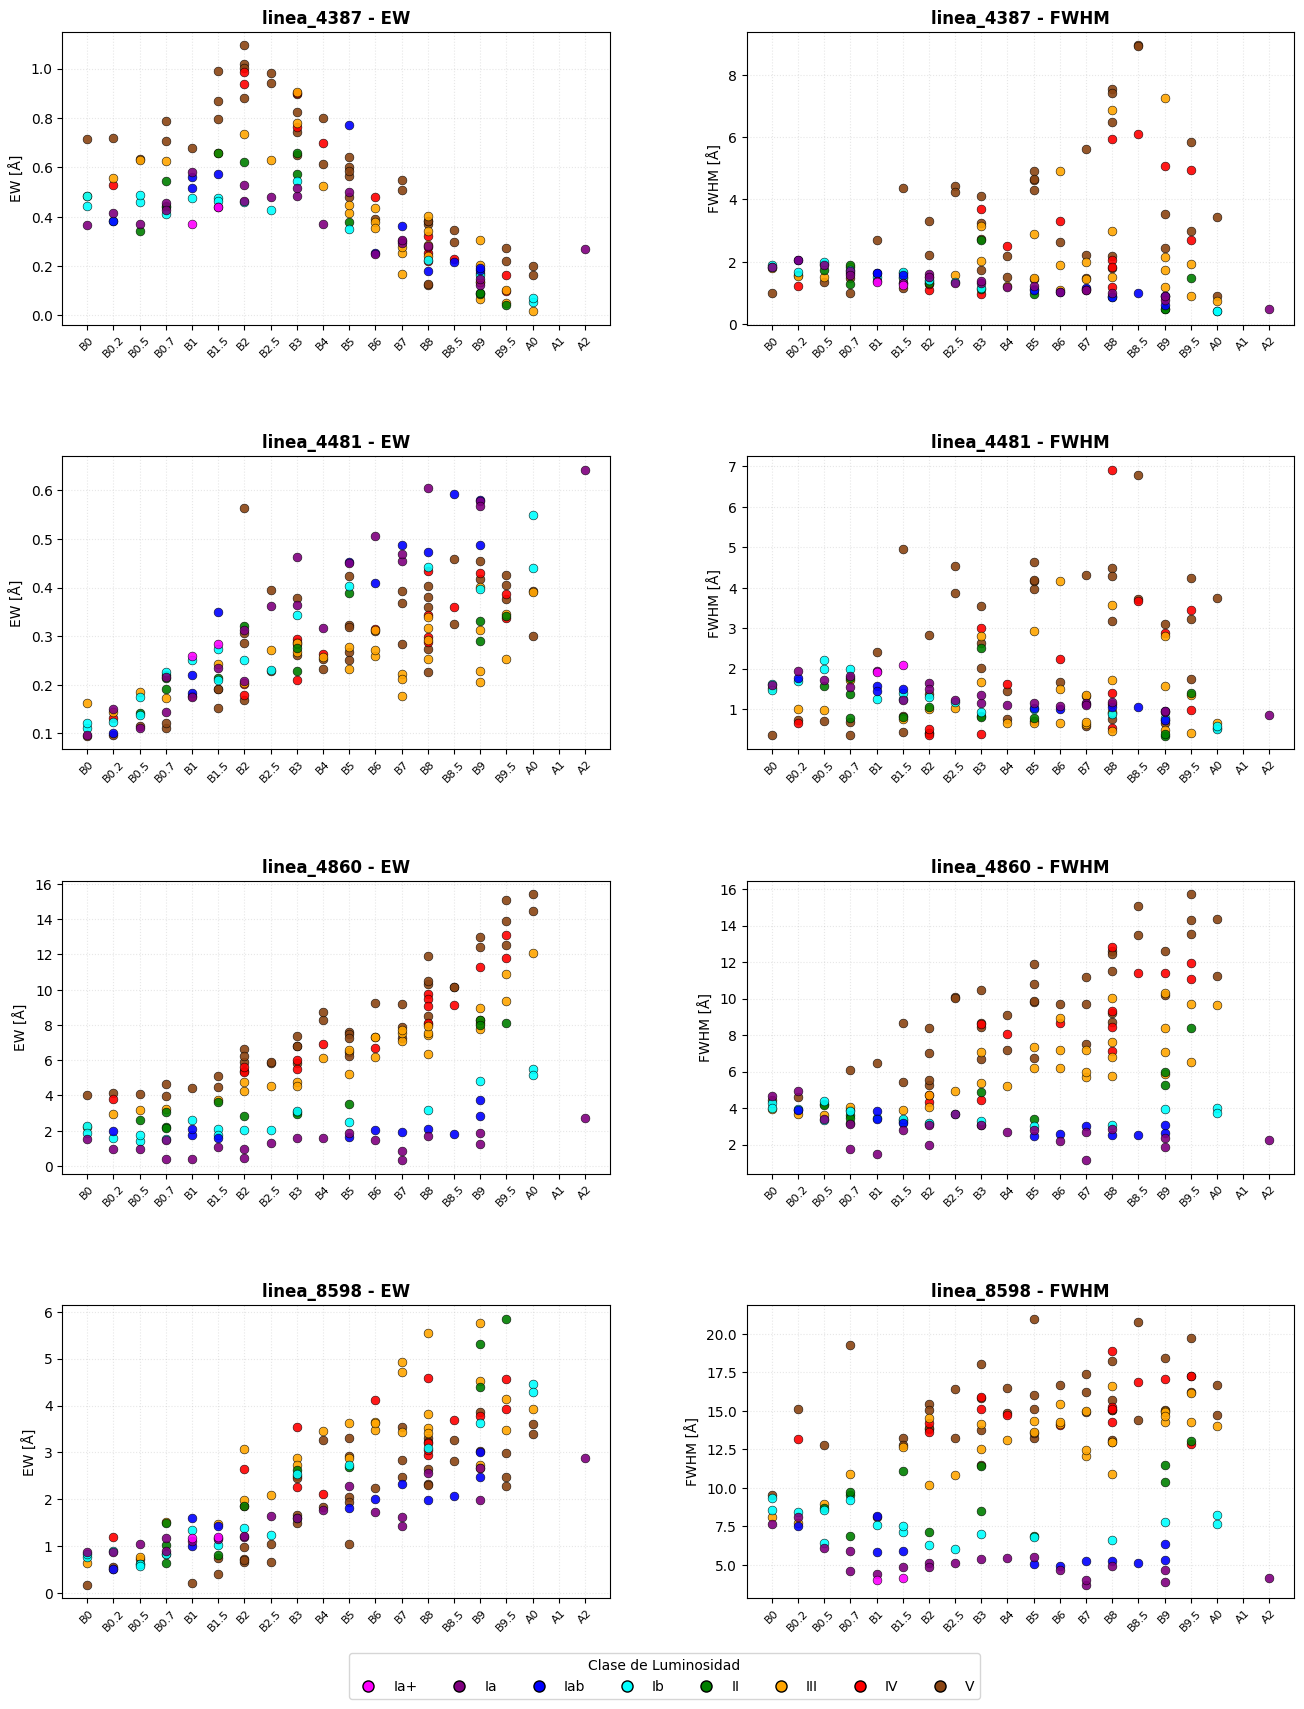

In [47]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# 1. Configuración de rutas
PATH_ANALISIS = r"C:\Users\User\Documents\TFG\Análisis"

# 2. Diccionario de estrellas
star_data_raw = {
    "HD37128": "B0 Ia", "HD205196": "B0 Ib", "HD164402": "B0 Ib", "HD48434": "B0 III",
    "HD149438": "B0 V", "HD171012": "B0.2 Ia", "HD204172": "B0.2 Iab", "HD16808": "B0.2 Ib",
    "HD6675": "B0.2 III", "HD36822": "B0.2 IV", "HD2083": "B0.2 V", "HD38771": "B0.5 Ia",
    "HD194839": "B0.5 Ia", "HD192422": "B0.5 Ib", "HD213087": "B0.5 Ib", "HD193007": "B0.5 II",
    "HD218376": "B0.5 III", "HD36960": "B0.5 V", "HD216411": "B0.7 Ia", "HD2905": "BC0.7 Ia",
    "HD190066": "B0.7 Ib", "HD190919": "B0.7 II", "HD193076": "B0.7 II", "HD14053": "B0.7 II",
    "HD13969": "B0.7 III", "HD37042": "B0.7 V", "HD201795": "B0.7 V", "HD169454": "B1 Ia+",
    "HD13256": "B1 Ia", "HD13854": "B1 Iab", "HD91316": "B1 Iab Ns", "HD24398": "B1 Ib",
    "HD44743": "B1 II–III", "HD144470": "B1 V", "HD24131": "B1 V", "HD190603": "B1.5 Ia+",
    "HD14956": "B1.5 Ia", "HD5551": "B1.5 Iab", "HD193183": "B1.5 Ib", "HD13841": "B1.5 Ib",
    "HD52089": "B1.5 II", "HD214993": "B1.5 III", "HD215191": "B1.5 V", "HD35299": "B1.5 V",
    "HD37744": "B1.5 V", "HD41117": "B2 Ia", "HD14143": "B2 Ia", "HD15690": "B2 Iab–Ib",
    "HD206165": "B2 Ib", "HD31327": "B2 II", "HD30836": "B2 III", "HD35468": "B2 III",
    "HD886": "B2 IV", "HD3360": "B2 IV", "HD36285": "B2 V", "HD36629": "B2 V",
    "HD144218": "B2 V", "HD208947": "B2 V", "HD198478": "B2.5 Ia", "HD42087": "B2.5 Ib",
    "HD207330": "B2.5 III", "HD148605": "B2.5 V", "HD175191": "B2.5 V", "HD14134": "B3 Ia",
    "HD53138": "B3 Ia", "HD51309": "B3 Ib", "HD36212": "B3 II", "HD194779": "B3 II",
    "HD21483": "B3 III", "HD49567": "B3 III", "HD3901": "B3 IV", "HD160762": "B3 IV",
    "HD20365": "B3 V", "HD32630": "B3 V", "HD120315": "B3 V", "HD178849": "B3 V",
    "HD36371": "B4 Ia", "HD164353": "B4 Ib–II", "HD41692": "B4 III", "HD180554": "B4 IV",
    "HD26739": "B4 V", "HD34759": "B4 V", "HD58350": "B5 Ia", "HD7902": "B5 Iab",
    "HD9311": "B5 Ib", "HD191243": "B5 II", "HD170682": "B5 III", "HD211924": "B5 III",
    "HD147394": "B5 V", "HD4142": "B5 V", "HD161572": "B5 V", "HD36936": "B5 V",
    "HD20809": "B5 V", "HD15497": "B6 Ia", "HD17145": "B6 Iab", "HD170719": "B6 III",
    "HD34503": "B6 III", "HD49340": "B6 III", "HD23338": "B6 IV", "HD90994": "B6 V",
    "HD183143": "B7 Ia", "HD199478": "B7 Ia", "HD208501": "B7 Iab", "HD35497": "B7 III",
    "HD23408": "B7 III", "HD1279": "B7 III", "HD23288": "B7 V", "HD21071": "B7 V",
    "HD182255": "B7 V", "HD34085": "B8 Ia", "HD14542": "B8 Iab", "HD12301": "B8 Ib",
    "HD23850": "B8 III", "HD155763": "B8 III", "HD179761": "B8 III", "HD10205": "B8 III",
    "HD17081": "B8 IV", "HD87901": "B8 IV", "HD3240": "B8 IV", "HD46075": "B8 IV",
    "HD23324": "B8 V", "HD23432": "B8 V", "HD21672": "B8 V", "HD171301": "B8 V",
    "HD224112": "B8 V", "HD184943": "B8.5 Iab", "HD214923": "B8.5 IV", "HD21279": "B8.5 V",
    "HD23923": "B8.5 V", "HD21291": "B9 Ia", "HD223960": "B9 Ia", "HD202850": "B9 Iab",
    "HD212593": "B9 Iab", "HD35600": "B9 Ib", "HD21661": "B9 II", "HD57608": "B9 II",
    "HD212097": "B9 III", "HD2011": "B9 III", "HD51688": "B9 III", "HD49606": "B9 III",
    "HD196867": "B9 IV", "HD21931": "B9 V", "HD38899": "B9 V", "HD176437": "B9.5 II",
    "HD181440": "B9.5 III", "HD144206": "B9.5 III", "HD186882": "B9.5 IV", "HD16046": "B9.5 IV",
    "HD23873": "B9.5 V", "HD23568": "B9.5 V", "HD222661": "B9.5 V", "HD21389": "A0 Ia",
    "HD46300": "A0 Ib", "HD87737": "A0 Ib", "HD123299": "A0 III", "HD103287": "A0 V",
    "HD172167": "A0 V", "HD197345": "A2 Ia"
}

star_data = {k.strip(): v for k, v in star_data_raw.items()}

# 3. Estética
spectral_order = ["B0", "B0.2", "B0.5", "B0.7", "B1", "B1.5", "B2", "B2.5", "B3", "B4", "B5", "B6", "B7", "B8", "B8.5", "B9", "B9.5", "A0", "A1", "A2"]
spec_to_num = {spec: i for i, spec in enumerate(spectral_order)}
lum_colors = {"Ia+": "#FF00FF", "Ia": "#800080", "Iab": "#0000FF", "Ib": "#00FFFF", "II": "#008000", "III": "#FFA500", "IV": "#FF0000", "V": "#8B4513"}

# 4. Procesamiento
files = sorted([f for f in os.listdir(PATH_ANALISIS) if f.endswith('.csv')])[:4] # Tomamos las 4 líneas principales

# Creamos la figura 4x2 (4 filas para líneas, 2 columnas para EW y FWHM)
fig, axes = plt.subplots(4, 2, figsize=(14, 18))

for i, file_name in enumerate(files):
    file_path = os.path.join(PATH_ANALISIS, file_name)
    data_list = []
    
    with open(file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        for line in lines[1:]:
            parts = line.strip().split(',')
            if len(parts) >= 3:
                nombre_estrella = parts[0].strip().replace(' ', '')
                if nombre_estrella in star_data:
                    # Corrección del error del split: info ya es el valor del dict
                    info = star_data[nombre_estrella] 
                    parts_info = info.split()
                    
                    data_list.append({
                        'X_Pos': spec_to_num.get(parts_info[0].replace('BC', 'B')),
                        'EW': float(parts[1]),
                        'FWHM': float(parts[2]),
                        'Lum': parts_info[1] if len(parts_info) > 1 else "V" # Por defecto V si no hay lum
                    })

    if data_list:
        df = pd.DataFrame(data_list)
        line_label = file_name.replace('.csv', '')

        # Columna 0: EW | Columna 1: FWHM
        for j, y_param in enumerate(['EW', 'FWHM']):
            ax = axes[i, j]
            
            for lum in reversed(list(lum_colors.keys())):
                sub = df[df['Lum'] == lum]
                if not sub.empty:
                    ax.scatter(sub['X_Pos'], sub[y_param], color=lum_colors[lum], 
                            edgecolors='black', s=40, alpha=0.9, linewidths=0.4, zorder=3)
            
            ax.set_title(f"{line_label} - {y_param}", fontweight='bold')
            ax.set_xticks(range(len(spectral_order)))
            ax.set_xticklabels(spectral_order, rotation=45, fontsize=8)
            ax.set_ylabel(f"{y_param} [Å]")
            ax.grid(alpha=0.3, linestyle=':')

# 5. Leyenda unificada inferior
handles = [plt.Line2D([0], [0], marker='o', color='w', label=l, 
        markerfacecolor=c, markersize=8, markeredgecolor='black', linestyle='None') 
        for l, c in lum_colors.items()]

fig.legend(handles=handles, title="Clase de Luminosidad", loc='lower center', 
        ncol=8, bbox_to_anchor=(0.5, 0.02), frameon=True)

plt.subplots_adjust(left=0.07, bottom=0.08, right=0.95, top=0.95, wspace=0.25, hspace=0.45)
plt.show()

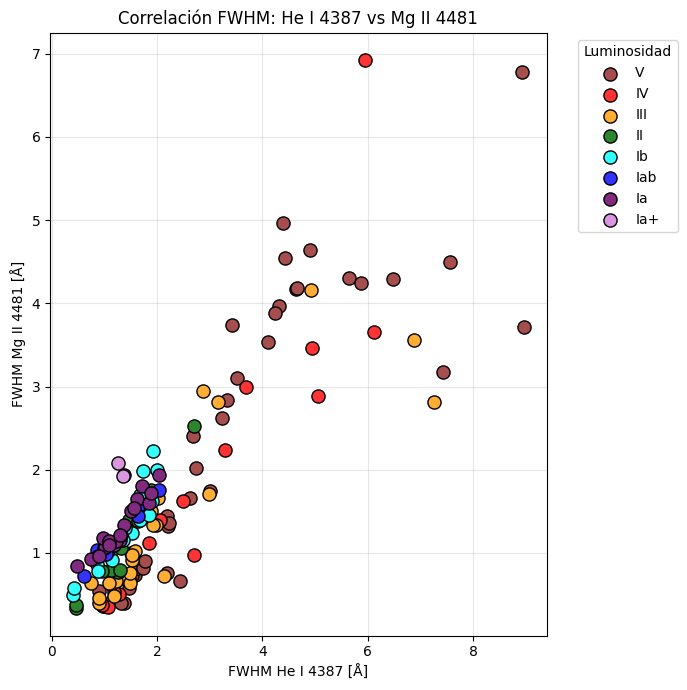

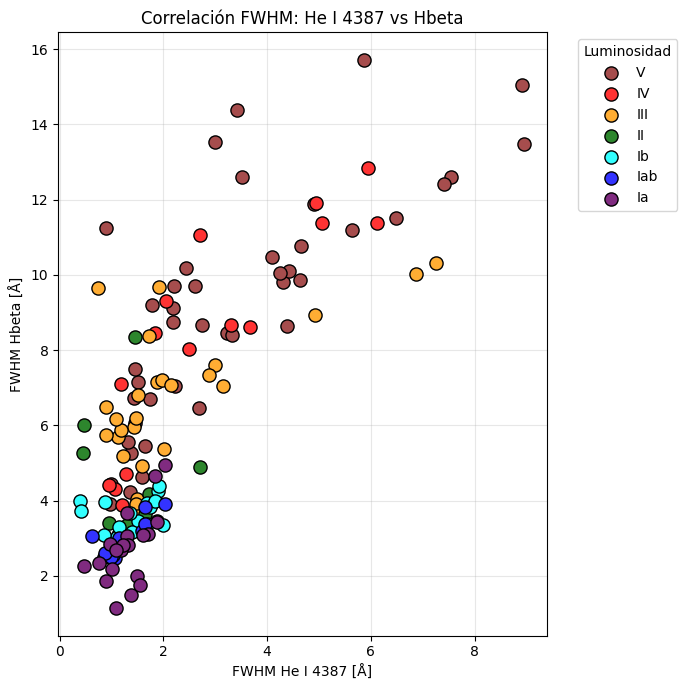

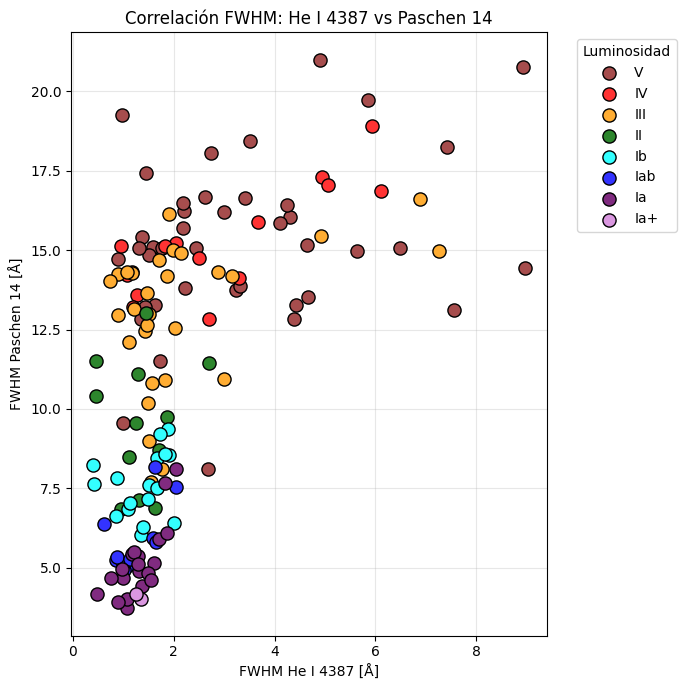

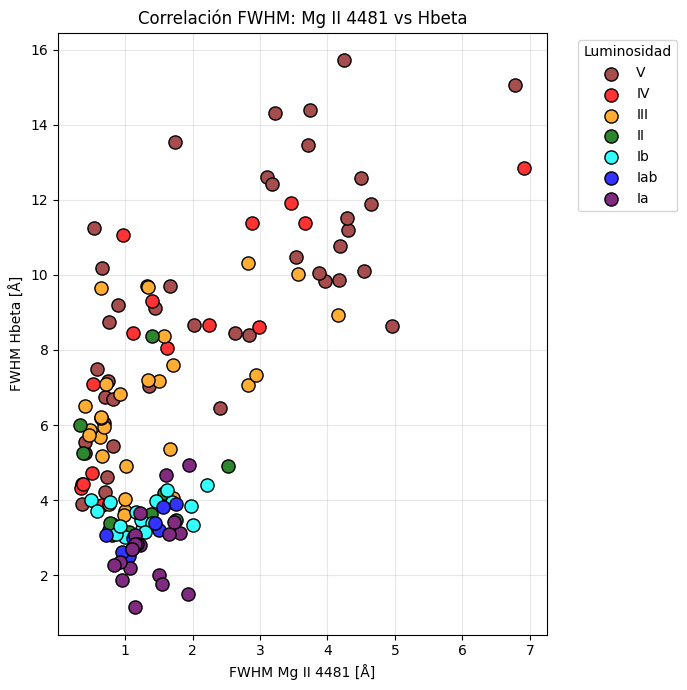

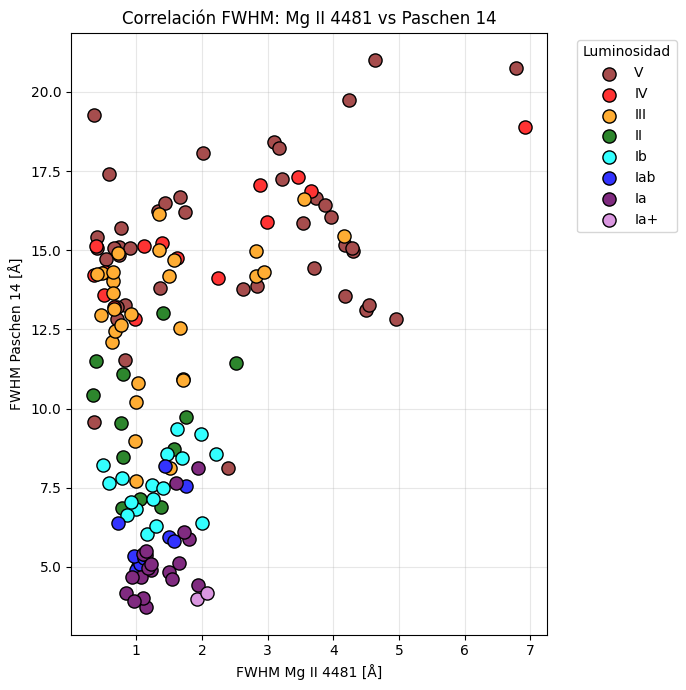

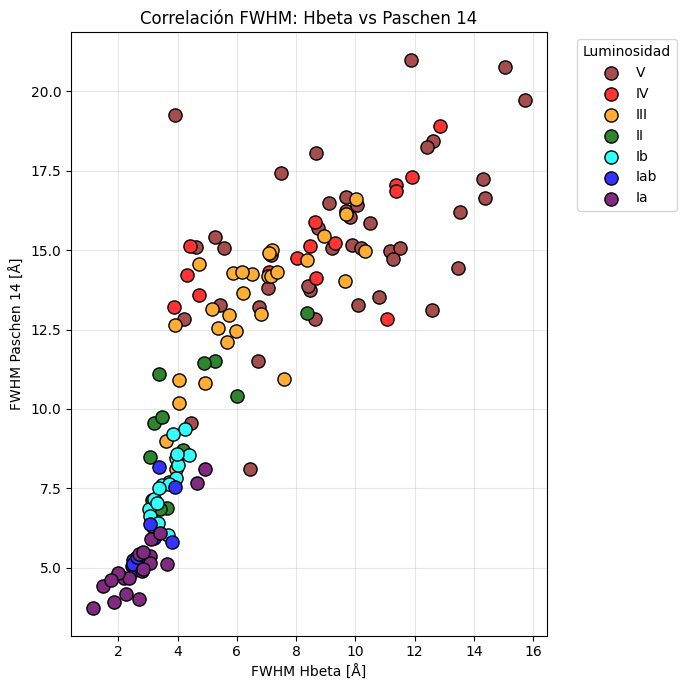


✨ Comparativa multi-línea finalizada.


In [48]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import re

# 1. Configuración de rutas
PATH_ANALISIS = r"C:\Users\User\Documents\TFG\Análisis"

# 2. Diccionario de estrellas (Normalizado)
star_data_raw = {
    "HD37128": "B0 Ia", "HD205196": "B0 Ib", "HD164402": "B0 Ib", "HD48434": "B0 III",
    "HD149438": "B0 V", "HD171012": "B0.2 Ia", "HD204172": "B0.2 Iab", "HD16808": "B0.2 Ib",
    "HD6675": "B0.2 III", "HD36822": "B0.2 IV", "HD2083": "B0.2 V", "HD38771": "B0.5 Ia",
    "HD194839": "B0.5 Ia", "HD192422": "B0.5 Ib", "HD213087": "B0.5 Ib", "HD193007": "B0.5 II",
    "HD218376": "B0.5 III", "HD36960": "B0.5 V", "HD216411": "B0.7 Ia", "HD2905": "BC0.7 Ia",
    "HD190066": "B0.7 Ib", "HD190919": "B0.7 II", "HD193076": "B0.7 II", "HD14053": "B0.7 II",
    "HD13969": "B0.7 III", "HD37042": "B0.7 V", "HD201795": "B0.7 V", "HD169454": "B1 Ia+",
    "HD13256": "B1 Ia", "HD13854": "B1 Iab", "HD91316": "B1 Iab Ns", "HD24398": "B1 Ib",
    "HD44743": "B1 II–III", "HD144470": "B1 V", "HD24131": "B1 V", "HD190603": "B1.5 Ia+",
    "HD14956": "B1.5 Ia", "HD5551": "B1.5 Iab", "HD193183": "B1.5 Ib", "HD13841": "B1.5 Ib",
    "HD52089": "B1.5 II", "HD214993": "B1.5 III", "HD215191": "B1.5 V", "HD35299": "B1.5 V",
    "HD37744": "B1.5 V", "HD41117": "B2 Ia", "HD14143": "B2 Ia", "HD15690": "B2 Iab–Ib",
    "HD206165": "B2 Ib", "HD31327": "B2 II", "HD30836": "B2 III", "HD35468": "B2 III",
    "HD886": "B2 IV", "HD3360": "B2 IV", "HD36285": "B2 V", "HD36629": "B2 V",
    "HD144218": "B2 V", "HD208947": "B2 V", "HD198478": "B2.5 Ia", "HD42087": "B2.5 Ib",
    "HD207330": "B2.5 III", "HD148605": "B2.5 V", "HD175191": "B2.5 V", "HD14134": "B3 Ia",
    "HD53138": "B3 Ia", "HD51309": "B3 Ib", "HD36212": "B3 II", "HD194779": "B3 II",
    "HD21483": "B3 III", "HD49567": "B3 III", "HD3901": "B3 IV", "HD160762": "B3 IV",
    "HD20365": "B3 V", "HD32630": "B3 V", "HD120315": "B3 V", "HD178849": "B3 V",
    "HD36371": "B4 Ia", "HD164353": "B4 Ib–II", "HD41692": "B4 III", "HD180554": "B4 IV",
    "HD26739": "B4 V", "HD34759": "B4 V", "HD58350": "B5 Ia", "HD7902": "B5 Iab",
    "HD9311": "B5 Ib", "HD191243": "B5 II", "HD170682": "B5 III", "HD211924": "B5 III",
    "HD147394": "B5 V", "HD4142": "B5 V", "HD161572": "B5 V", "HD36936": "B5 V",
    "HD20809": "B5 V", "HD15497": "B6 Ia", "HD17145": "B6 Iab", "HD170719": "B6 III",
    "HD34503": "B6 III", "HD49340": "B6 III", "HD23338": "B6 IV", "HD90994": "B6 V",
    "HD183143": "B7 Ia", "HD199478": "B7 Ia", "HD208501": "B7 Iab", "HD35497": "B7 III",
    "HD23408": "B7 III", "HD1279": "B7 III", "HD23288": "B7 V", "HD21071": "B7 V",
    "HD182255": "B7 V", "HD34085": "B8 Ia", "HD14542": "B8 Iab", "HD12301": "B8 Ib",
    "HD23850": "B8 III", "HD155763": "B8 III", "HD179761": "B8 III", "HD10205": "B8 III",
    "HD17081": "B8 IV", "HD87901": "B8 IV", "HD3240": "B8 IV", "HD46075": "B8 IV",
    "HD23324": "B8 V", "HD23432": "B8 V", "HD21672": "B8 V", "HD171301": "B8 V",
    "HD224112": "B8 V", "HD184943": "B8.5 Iab", "HD214923": "B8.5 IV", "HD21279": "B8.5 V",
    "HD23923": "B8.5 V", "HD21291": "B9 Ia", "HD223960": "B9 Ia", "HD202850": "B9 Iab",
    "HD212593": "B9 Iab", "HD35600": "B9 Ib", "HD21661": "B9 II", "HD57608": "B9 II",
    "HD212097": "B9 III", "HD2011": "B9 III", "HD51688": "B9 III", "HD49606": "B9 III",
    "HD196867": "B9 IV", "HD21931": "B9 V", "HD38899": "B9 V", "HD176437": "B9.5 II",
    "HD181440": "B9.5 III", "HD144206": "B9.5 III", "HD186882": "B9.5 IV", "HD16046": "B9.5 IV",
    "HD23873": "B9.5 V", "HD23568": "B9.5 V", "HD222661": "B9.5 V", "HD21389": "A0 Ia",
    "HD46300": "A0 Ib", "HD87737": "A0 Ib", "HD123299": "A0 III", "HD103287": "A0 V",
    "HD172167": "A0 V", "HD197345": "A2 Ia"
}
star_data = {k.strip(): v for k, v in star_data_raw.items()}

# 3. Estética
lum_colors = {"Ia+": "#da97e0", "Ia": "#802b80", "Iab": "#3333ff", "Ib": "#33ffff", "II": "#2d862d", "III": "#ffad33", "IV": "#ff3333", "V": "#a64d4d"}

# --- FUNCIÓN DE IDENTIFICACIÓN ---
def obtener_nombre_linea(nombre_archivo):
    match = re.search(r'\d+', nombre_archivo)
    if not match: return nombre_archivo
    wvl = int(match.group())
    
    if wvl == 4481: return "Mg II 4481"
    if wvl == 4387: return "He I 4387"
    if wvl == 4860: return "Hbeta"
    if wvl == 8598: return "Paschen 14"
    return f"Línea {wvl} Å"

# --- PROCESAMIENTO ---
files = sorted([f for f in os.listdir(PATH_ANALISIS) if f.endswith('.csv')])
all_lines_data = {}

for file_name in files:
    file_path = os.path.join(PATH_ANALISIS, file_name)
    line_dict = {}
    with open(file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        for line in lines[1:]:
            parts = line.strip().split(',')
            if len(parts) >= 3:
                nombre = parts[0].strip().replace(' ', '')
                if nombre in star_data:
                    line_dict[nombre] = float(parts[2])
    if line_dict:
        all_lines_data[file_name] = line_dict

line_names = list(all_lines_data.keys())

for i in range(len(line_names)):
    for j in range(i + 1, len(line_names)):
        file_a, file_b = line_names[i], line_names[j]
        label_a, label_b = obtener_nombre_linea(file_a), obtener_nombre_linea(file_b)
        
        comparacion_list = []
        for star, fwhm_a in all_lines_data[file_a].items():
            if star in all_lines_data[file_b]:
                comparacion_list.append({
                    'FWHM_A': fwhm_a, 'FWHM_B': all_lines_data[file_b][star],
                    'Lum': star_data[star].split()[1] if len(star_data[star].split()) > 1 else "ERR"
                })
        
        if comparacion_list:
            df_comp = pd.DataFrame(comparacion_list)
            plt.figure(figsize=(7, 7))
            for lum in reversed(list(lum_colors.keys())):
                sub = df_comp[df_comp['Lum'] == lum]
                if not sub.empty:
                    plt.scatter(sub['FWHM_A'], sub['FWHM_B'], color=lum_colors[lum], 
                                label=lum, edgecolors='black', s=90, zorder=3)
            
            plt.title(f"Correlación FWHM: {label_a} vs {label_b}")
            plt.xlabel(f"FWHM {label_a} [Å]")
            plt.ylabel(f"FWHM {label_b} [Å]")
            plt.legend(title="Luminosidad", bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.grid(alpha=0.3, zorder=0)
            plt.tight_layout()
            plt.show()

print("\n✨ Comparativa multi-línea finalizada.")

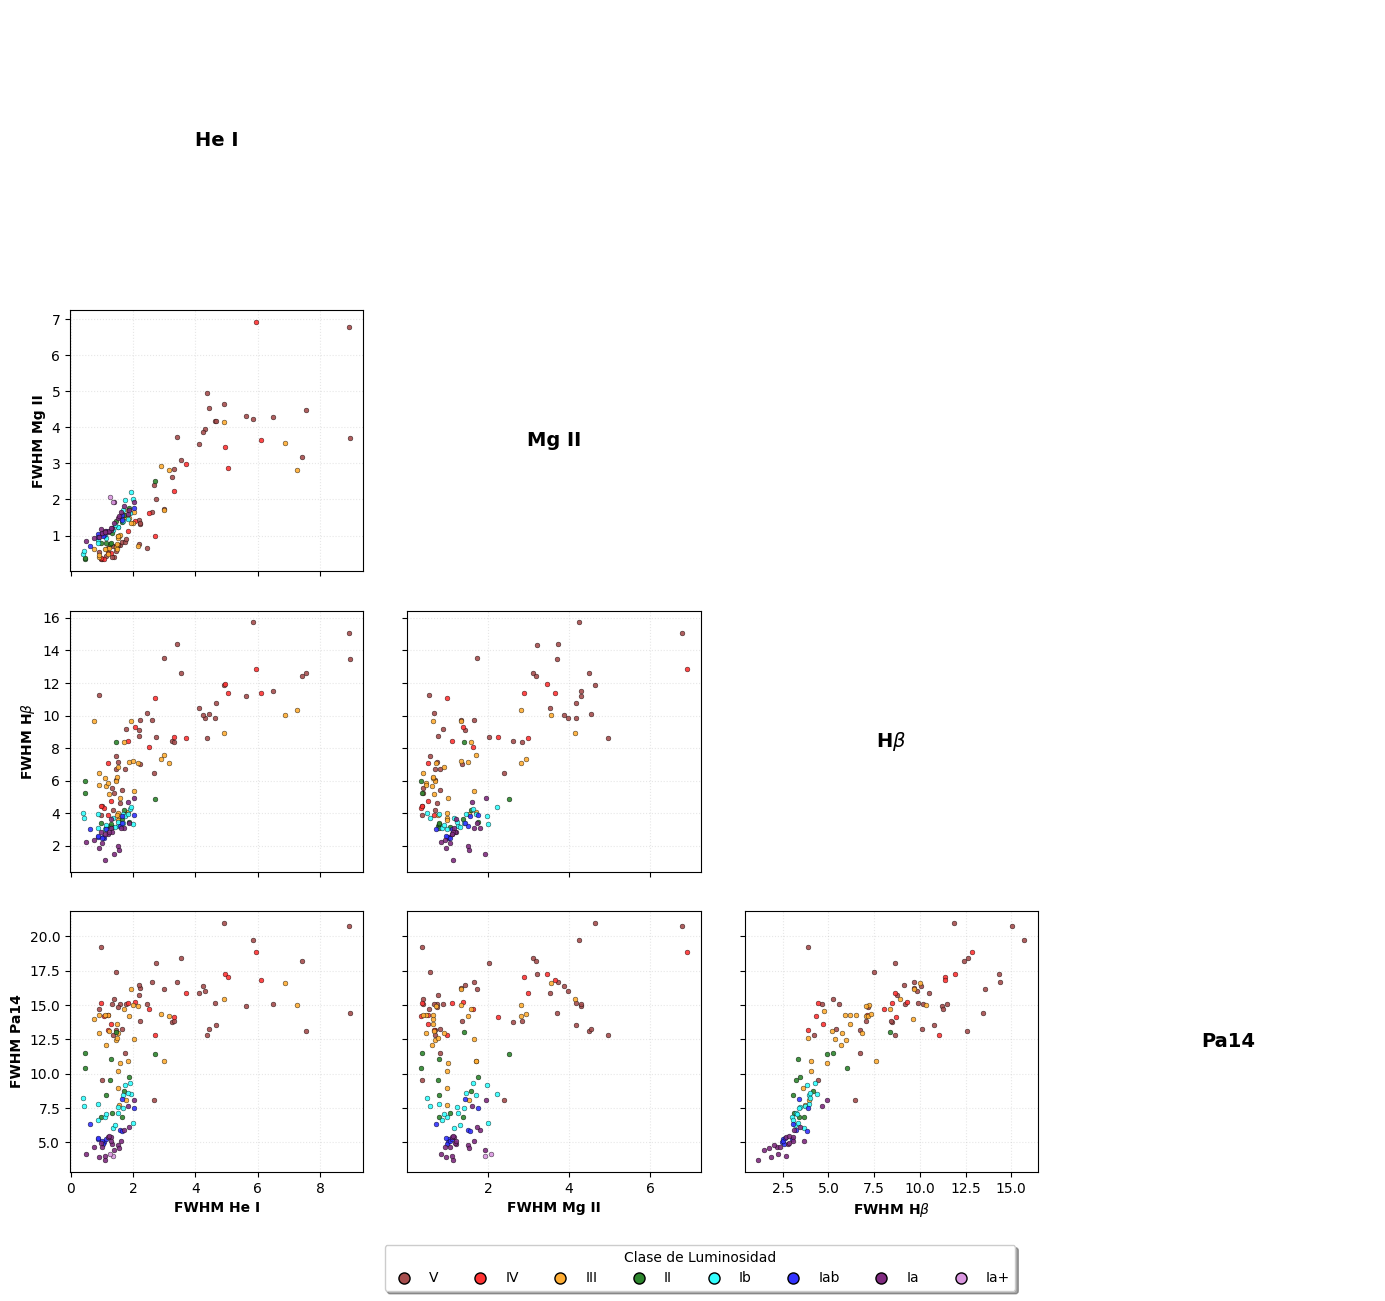


✅ Matriz triangular de correlaciones finalizada.


In [49]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import re

# 1. Configuración de rutas
PATH_ANALISIS = r"C:\Users\User\Documents\TFG\Análisis"

# 2. Diccionario de estrellas
star_data_raw = {
    "HD37128": "B0 Ia", "HD205196": "B0 Ib", "HD164402": "B0 Ib", "HD48434": "B0 III",
    "HD149438": "B0 V", "HD171012": "B0.2 Ia", "HD204172": "B0.2 Iab", "HD16808": "B0.2 Ib",
    "HD6675": "B0.2 III", "HD36822": "B0.2 IV", "HD2083": "B0.2 V", "HD38771": "B0.5 Ia",
    "HD194839": "B0.5 Ia", "HD192422": "B0.5 Ib", "HD213087": "B0.5 Ib", "HD193007": "B0.5 II",
    "HD218376": "B0.5 III", "HD36960": "B0.5 V", "HD216411": "B0.7 Ia", "HD2905": "BC0.7 Ia",
    "HD190066": "B0.7 Ib", "HD190919": "B0.7 II", "HD193076": "B0.7 II", "HD14053": "B0.7 II",
    "HD13969": "B0.7 III", "HD37042": "B0.7 V", "HD201795": "B0.7 V", "HD169454": "B1 Ia+",
    "HD13256": "B1 Ia", "HD13854": "B1 Iab", "HD91316": "B1 Iab Ns", "HD24398": "B1 Ib",
    "HD44743": "B1 II–III", "HD144470": "B1 V", "HD24131": "B1 V", "HD190603": "B1.5 Ia+",
    "HD14956": "B1.5 Ia", "HD5551": "B1.5 Iab", "HD193183": "B1.5 Ib", "HD13841": "B1.5 Ib",
    "HD52089": "B1.5 II", "HD214993": "B1.5 III", "HD215191": "B1.5 V", "HD35299": "B1.5 V",
    "HD37744": "B1.5 V", "HD41117": "B2 Ia", "HD14143": "B2 Ia", "HD15690": "B2 Iab–Ib",
    "HD206165": "B2 Ib", "HD31327": "B2 II", "HD30836": "B2 III", "HD35468": "B2 III",
    "HD886": "B2 IV", "HD3360": "B2 IV", "HD36285": "B2 V", "HD36629": "B2 V",
    "HD144218": "B2 V", "HD208947": "B2 V", "HD198478": "B2.5 Ia", "HD42087": "B2.5 Ib",
    "HD207330": "B2.5 III", "HD148605": "B2.5 V", "HD175191": "B2.5 V", "HD14134": "B3 Ia",
    "HD53138": "B3 Ia", "HD51309": "B3 Ib", "HD36212": "B3 II", "HD194779": "B3 II",
    "HD21483": "B3 III", "HD49567": "B3 III", "HD3901": "B3 IV", "HD160762": "B3 IV",
    "HD20365": "B3 V", "HD32630": "B3 V", "HD120315": "B3 V", "HD178849": "B3 V",
    "HD36371": "B4 Ia", "HD164353": "B4 Ib–II", "HD41692": "B4 III", "HD180554": "B4 IV",
    "HD26739": "B4 V", "HD34759": "B4 V", "HD58350": "B5 Ia", "HD7902": "B5 Iab",
    "HD9311": "B5 Ib", "HD191243": "B5 II", "HD170682": "B5 III", "HD211924": "B5 III",
    "HD147394": "B5 V", "HD4142": "B5 V", "HD161572": "B5 V", "HD36936": "B5 V",
    "HD20809": "B5 V", "HD15497": "B6 Ia", "HD17145": "B6 Iab", "HD170719": "B6 III",
    "HD34503": "B6 III", "HD49340": "B6 III", "HD23338": "B6 IV", "HD90994": "B6 V",
    "HD183143": "B7 Ia", "HD199478": "B7 Ia", "HD208501": "B7 Iab", "HD35497": "B7 III",
    "HD23408": "B7 III", "HD1279": "B7 III", "HD23288": "B7 V", "HD21071": "B7 V",
    "HD182255": "B7 V", "HD34085": "B8 Ia", "HD14542": "B8 Iab", "HD12301": "B8 Ib",
    "HD23850": "B8 III", "HD155763": "B8 III", "HD179761": "B8 III", "HD10205": "B8 III",
    "HD17081": "B8 IV", "HD87901": "B8 IV", "HD3240": "B8 IV", "HD46075": "B8 IV",
    "HD23324": "B8 V", "HD23432": "B8 V", "HD21672": "B8 V", "HD171301": "B8 V",
    "HD224112": "B8 V", "HD184943": "B8.5 Iab", "HD214923": "B8.5 IV", "HD21279": "B8.5 V",
    "HD23923": "B8.5 V", "HD21291": "B9 Ia", "HD223960": "B9 Ia", "HD202850": "B9 Iab",
    "HD212593": "B9 Iab", "HD35600": "B9 Ib", "HD21661": "B9 II", "HD57608": "B9 II",
    "HD212097": "B9 III", "HD2011": "B9 III", "HD51688": "B9 III", "HD49606": "B9 III",
    "HD196867": "B9 IV", "HD21931": "B9 V", "HD38899": "B9 V", "HD176437": "B9.5 II",
    "HD181440": "B9.5 III", "HD144206": "B9.5 III", "HD186882": "B9.5 IV", "HD16046": "B9.5 IV",
    "HD23873": "B9.5 V", "HD23568": "B9.5 V", "HD222661": "B9.5 V", "HD21389": "A0 Ia",
    "HD46300": "A0 Ib", "HD87737": "A0 Ib", "HD123299": "A0 III", "HD103287": "A0 V",
    "HD172167": "A0 V", "HD197345": "A2 Ia"
}

star_data = {k.strip(): v for k, v in star_data_raw.items()}

# 3. Estética (Colores y Orden)
orden_logico = ["V", "IV", "III", "II", "Ib", "Iab", "Ia", "Ia+"]
lum_colors = {
    "V": "#a64d4d", "IV": "#ff3333", "III": "#ffad33", "II": "#2d862d", 
    "Ib": "#33ffff", "Iab": "#3333ff", "Ia": "#802b80", "Ia+": "#da97e0"
}

# Parámetros minimalistas que definimos antes
TAMANO_PUNTO = 12 
OPACIDAD = 0.9

def obtener_nombre_linea(nombre_archivo):
    match = re.search(r'\d+', nombre_archivo)
    if not match: return nombre_archivo
    wvl = int(match.group())
    lineas = {4481: "Mg II", 4387: "He I", 4860: r"H$\beta$", 8598: "Pa14"}
    return lineas.get(wvl, f"{wvl} Å")

# 4. Procesamiento de datos
files = sorted([f for f in os.listdir(PATH_ANALISIS) if f.endswith('.csv')])
all_lines_data = {}

for file_name in files:
    file_path = os.path.join(PATH_ANALISIS, file_name)
    line_dict = {}
    with open(file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        for line in lines[1:]:
            parts = line.strip().split(',')
            if len(parts) >= 3:
                nombre = parts[0].strip().replace(' ', '')
                if nombre in star_data:
                    line_dict[nombre] = float(parts[2]) # Usamos FWHM
    if line_dict:
        all_lines_data[file_name] = line_dict

line_keys = list(all_lines_data.keys())
n = len(line_keys)

# 5. Generación de Matriz Triangular
fig, axes = plt.subplots(n, n, figsize=(15, 14), sharex='col', sharey='row')

lums_presentes = set()

for i in range(n):
    for j in range(n):
        ax = axes[i, j]
        label_y = obtener_nombre_linea(line_keys[i])
        label_x = obtener_nombre_linea(line_keys[j])

        # A. Eliminar triángulo superior
        if j > i:
            ax.axis('off')
            continue
            
        # B. Diagonal: Solo nombres de las líneas
        if i == j:
            ax.axis('off')
            ax.text(0.5, 0.5, label_x, transform=ax.transAxes, ha='center', va='center',
                    weight='bold', fontsize=14, color='black', 
                    bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))
            continue
            
        # C. Triángulo inferior: Gráficos de correlación
        file_y, file_x = line_keys[i], line_keys[j]
        common_stars = []
        for star, fwhm_y in all_lines_data[file_y].items():
            if star in all_lines_data[file_x]:
                info_parts = star_data[star].split()
                lum = info_parts[1] if len(info_parts) > 1 else "V"
                common_stars.append({'y': fwhm_y, 'x': all_lines_data[file_x][star], 'lum': lum})
        
        if common_stars:
            df = pd.DataFrame(common_stars)
            for lum in orden_logico:
                sub = df[df['lum'] == lum]
                if not sub.empty:
                    lums_presentes.add(lum)
                    ax.scatter(sub['x'], sub['y'], color=lum_colors.get(lum, "#808080"), 
                            edgecolors='black', s=TAMANO_PUNTO, alpha=OPACIDAD, 
                            linewidths=0.3, zorder=3)
        
        ax.grid(True, linestyle=':', alpha=0.3)
        
        # Etiquetas exteriores
        if i == n-1: ax.set_xlabel(f"FWHM {label_x}", fontsize=10, fontweight='bold')
        if j == 0: ax.set_ylabel(f"FWHM {label_y}", fontsize=10, fontweight='bold')

# 6. Leyenda única abajo
handles_lum = [plt.Line2D([0], [0], marker='o', color='w', label=l, 
            markerfacecolor=lum_colors[l], markersize=8, markeredgecolor='black', linestyle='None') 
            for l in orden_logico if l in lums_presentes]

fig.legend(handles=handles_lum, title="Clase de Luminosidad", loc='lower center', 
        ncol=len(handles_lum), bbox_to_anchor=(0.5, 0.03), frameon=True, shadow=True)

plt.subplots_adjust(left=0.08, bottom=0.12, right=0.95, top=0.95, wspace=0.15, hspace=0.15)
plt.show()

print("\n✅ Matriz triangular de correlaciones finalizada.")

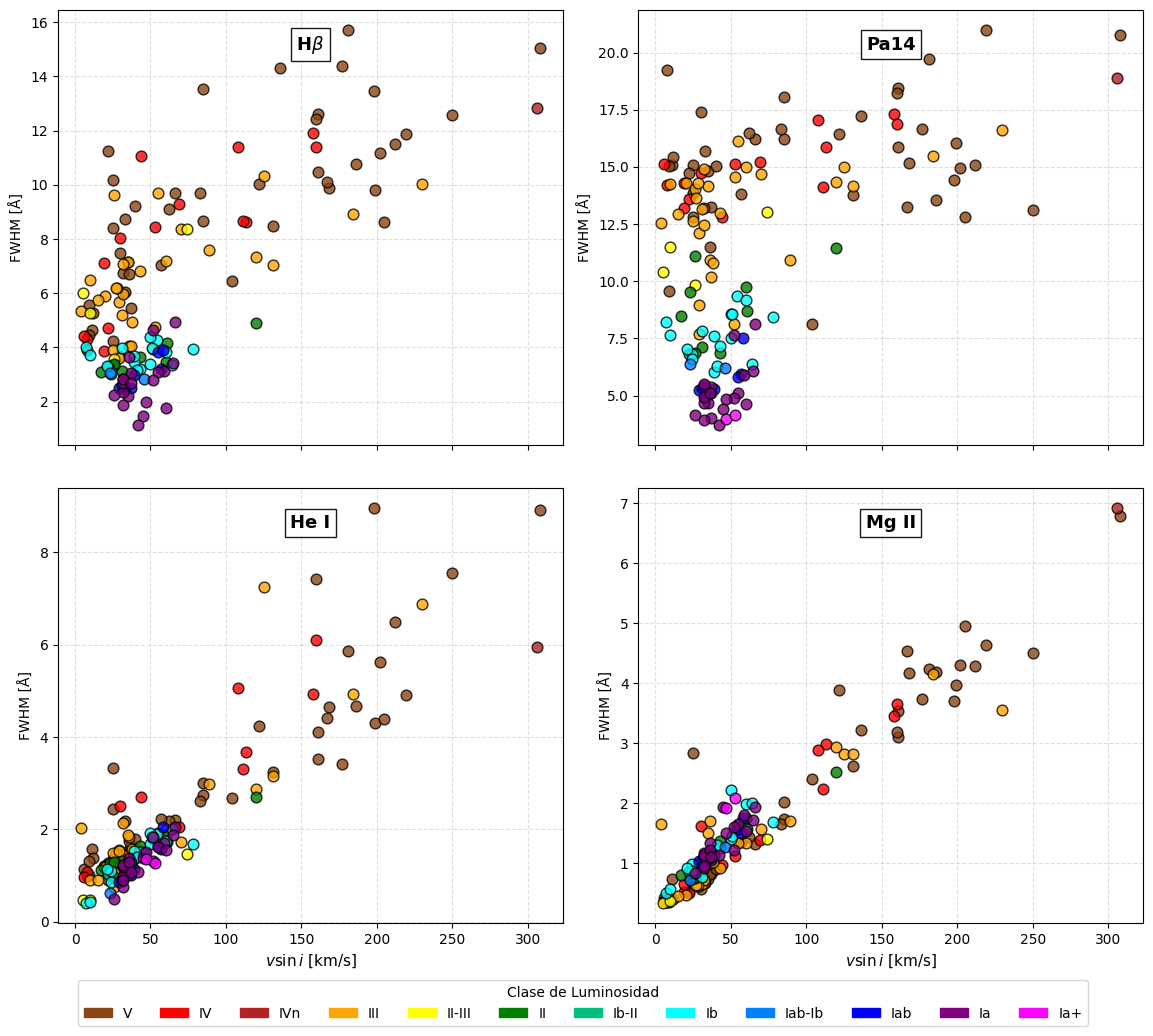


✨ Panel 2x2 de vsini vs FWHM generado.


In [50]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import re

# 1. Configuración de rutas
PATH_ANALISIS = r"C:\Users\User\Documents\TFG\Análisis"

# 2. DICCIONARIO
star_data_raw = {
    "HD37128":  {"SpC": "B0 Ia", "vsini": 52}, "HD205196": {"SpC": "B0 Ib", "vsini": 51},
    "HD164402": {"SpC": "B0 Ib", "vsini": 54}, "HD48434":  {"SpC": "B0 III", "vsini": 52},
    "HD149438": {"SpC": "B0 V", "vsini": 9}, "HD171012": {"SpC": "B0.2 Ia", "vsini": 66},
    "HD204172": {"SpC": "B0.2 Iab", "vsini": 58}, "HD16808":  {"SpC": "B0.2 Ib", "vsini": 78},
    "HD6675":   {"SpC": "B0.2 III", "vsini": 29}, "HD36822":  {"SpC": "B0.2 IV", "vsini": 19},
    "HD2083":   {"SpC": "B0.2 V", "vsini": 11}, "HD38771":  {"SpC": "B0.5 Ia", "vsini": 47},
    "HD194839": {"SpC": "B0.5 Ia", "vsini": 65}, "HD192422": {"SpC": "B0.5 Ib", "vsini": 50},
    "HD213087": {"SpC": "B0.5 Ib", "vsini": 64}, "HD193007": {"SpC": "B0.5 II", "vsini": 61},
    "HD218376": {"SpC": "B0.5 III", "vsini": 29}, "HD36960":  {"SpC": "B0.5 V", "vsini": 25},
    "HD216411": {"SpC": "B0.7 Ia", "vsini": 60}, "HD2905":   {"SpC": "BC0.7 Ia", "vsini": 59},
    "HD190066": {"SpC": "B0.7 Ib", "vsini": 60}, "HD190919": {"SpC": "B0.7 II", "vsini": 43},
    "HD193076": {"SpC": "B0.7 II", "vsini": 60}, "HD14053":  {"SpC": "B0.7 II", "vsini": 23},
    "HD13969":  {"SpC": "B0.7 III", "vsini": 36}, "HD37042":  {"SpC": "B0.7 V", "vsini": 33},
    "HD201795": {"SpC": "B0.7 V", "vsini": 8}, "HD169454": {"SpC": "B1 Ia+", "vsini": 47},
    "HD13256":  {"SpC": "B1 Ia", "vsini": 45}, "HD13854":  {"SpC": "B1 Iab", "vsini": 55},
    "HD91316":  {"SpC": "B1 Iab Ns", "vsini": 47}, "HD24398":  {"SpC": "B1 Ib", "vsini": 39},
    "HD44743":  {"SpC": "B1 II-III", "vsini": 26}, "HD144470": {"SpC": "B1 V", "vsini": 104},
    "HD24131":  {"SpC": "B1 V", "vsini": 80}, "HD190603": {"SpC": "B1.5 Ia+", "vsini": 53},
    "HD14956":  {"SpC": "B1.5 Ia", "vsini": 52}, "HD5551":   {"SpC": "B1.5 Iab", "vsini": 57},
    "HD193183": {"SpC": "B1.5 Ib", "vsini": 50}, "HD13841":  {"SpC": "B1.5 Ib", "vsini": 43},
    "HD52089":  {"SpC": "B1.5 II", "vsini": 26}, "HD214993": {"SpC": "B1.5 III", "vsini": 25},
    "HD215191": {"SpC": "B1.5 V", "vsini": 205}, "HD35299":  {"SpC": "B1.5 V", "vsini": 6},
    "HD37744":  {"SpC": "B1.5 V", "vsini": 37}, "HD41117":  {"SpC": "B2 Ia", "vsini": 47},
    "HD14143":  {"SpC": "B2 Ia", "vsini": 55}, "HD15690":  {"SpC": "B2 Iab-Ib", "vsini": 46},
    "HD206165": {"SpC": "B2 Ib", "vsini": 41}, "HD31327":  {"SpC": "B2 II", "vsini": 31},
    "HD30836":  {"SpC": "B2 III", "vsini": 37}, "HD35468":  {"SpC": "B2 III", "vsini": 53},
    "HD886":    {"SpC": "B2 IV", "vsini": 8}, "HD3360":    {"SpC": "B2 IV", "vsini": 22},
    "HD36285":  {"SpC": "B2 V", "vsini": 12}, "HD36629":  {"SpC": "B2 V", "vsini": 9},
    "HD144218": {"SpC": "B2 V", "vsini": 57}, "HD208947": {"SpC": "B2 V", "vsini": 25},
    "HD198478": {"SpC": "B2.5 Ia", "vsini": 36}, "HD42087":  {"SpC": "B2.5 Ib", "vsini": 39},
    "HD207330": {"SpC": "B2.5 III", "vsini": 38}, "HD148605": {"SpC": "B2.5 V", "vsini": 167},
    "HD175191": {"SpC": "B2.5 V", "vsini": 122}, "HD14134":  {"SpC": "B3 Ia", "vsini": 37},
    "HD53138":  {"SpC": "B3 Ia", "vsini": 36}, "HD51309":  {"SpC": "B3 Ib", "vsini": 21},
    "HD36212":  {"SpC": "B3 II", "vsini": 17}, "HD194779": {"SpC": "B3 II", "vsini": 120},
    "HD21483":  {"SpC": "B3 III", "vsini": 131}, "HD49567":  {"SpC": "B3 III", "vsini": 4},
    "HD3901":   {"SpC": "B3 IV", "vsini": 113}, "HD160762": {"SpC": "B3 IV", "vsini": 6},
    "HD20365":  {"SpC": "B3 V", "vsini": 131}, "HD32630":  {"SpC": "B3 V", "vsini": 85},
    "HD120315": {"SpC": "B3 V", "vsini": 161}, "HD178849": {"SpC": "B3 V", "vsini": 36},
    "HD36371":  {"SpC": "B4 Ia", "vsini": 32}, "HD164353": {"SpC": "B4 Ib-II", "vsini": 22},
    "HD41692":  {"SpC": "B4 III", "vsini": 31}, "HD180554": {"SpC": "B4 IV", "vsini": 30},
    "HD26739":  {"SpC": "B4 V", "vsini": 35}, "HD34759":  {"SpC": "B4 V", "vsini": 62},
    "HD58350":  {"SpC": "B5 Ia", "vsini": 32}, "HD7902":    {"SpC": "B5 Iab", "vsini": 33},
    "HD9311":   {"SpC": "B5 Ib", "vsini": 24}, "HD191243": {"SpC": "B5 II", "vsini": 26},
    "HD170682": {"SpC": "B5 III", "vsini": 120}, "HD211924": {"SpC": "B5 III", "vsini": 27},
    "HD147394": {"SpC": "B5 V", "vsini": 32}, "HD4142":   {"SpC": "B5 V", "vsini": 199},
    "HD161572": {"SpC": "B5 V", "vsini": 186}, "HD36936":  {"SpC": "B5 V", "vsini": 219},
    "HD20809":  {"SpC": "B5 V", "vsini": 168}, "HD15497":  {"SpC": "B6 Ia", "vsini": 35},
    "HD17145":  {"SpC": "B6 Iab", "vsini": 33}, "HD170719": {"SpC": "B6 III", "vsini": 28},
    "HD34503":  {"SpC": "B6 III", "vsini": 35}, "HD49340":  {"SpC": "B6 III", "vsini": 184},
    "HD23338":  {"SpC": "B6 IV", "vsini": 111}, "HD90994":  {"SpC": "B6 V", "vsini": 83},
    "HD183143": {"SpC": "B7 Ia", "vsini": 42}, "HD199478": {"SpC": "B7 Ia", "vsini": 37},
    "HD208501": {"SpC": "B7 Iab", "vsini": 39}, "HD35497":  {"SpC": "B7 III", "vsini": 60},
    "HD23408":  {"SpC": "B7 III", "vsini": 32}, "HD1279":   {"SpC": "B7 III", "vsini": 29},
    "HD23288":  {"SpC": "B7 V", "vsini": 202}, "HD21071":  {"SpC": "B7 V", "vsini": 66},
    "HD182255": {"SpC": "B7 V", "vsini": 30}, "HD34085":  {"SpC": "B8 Ia", "vsini": 32},
    "HD14542":  {"SpC": "B8 Iab", "vsini": 29}, "HD12301":  {"SpC": "B8 Ib", "vsini": 24},
    "HD23850":  {"SpC": "B8 III", "vsini": 230}, "HD155763": {"SpC": "B8 III", "vsini": 43},
    "HD179761": {"SpC": "B8 III", "vsini": 15}, "HD10205":  {"SpC": "B8 III", "vsini": 89},
    "HD17081":  {"SpC": "B8 IV", "vsini": 19}, "HD87901":  {"SpC": "B8 IVn", "vsini": 306},
    "HD3240":   {"SpC": "B8 IV", "vsini": 69}, "HD46075":  {"SpC": "B8 IV", "vsini": 53},
    "HD23324":  {"SpC": "B8 V", "vsini": 212}, "HD23432":  {"SpC": "B8 V", "vsini": 160},
    "HD21672":  {"SpC": "B8 V", "vsini": 250}, "HD171301": {"SpC": "B8 V", "vsini": 33},
    "HD224112": {"SpC": "B8 V", "vsini": 40}, "HD184943": {"SpC": "B8.5 Iab", "vsini": 37},
    "HD214923": {"SpC": "B8.5 IV", "vsini": 160}, "HD21279":  {"SpC": "B8.5 V", "vsini": 198},
    "HD23923":  {"SpC": "B8.5 V", "vsini": 308}, "HD21291":  {"SpC": "B9 Ia", "vsini": 32},
    "HD223960": {"SpC": "B9 Ia", "vsini": 32}, "HD202850": {"SpC": "B9 Iab", "vsini": 31},
    "HD212593": {"SpC": "B9 Iab-Ib", "vsini": 23}, "HD35600":  {"SpC": "B9 Ib", "vsini": 31},
    "HD21661":  {"SpC": "B9 II-III", "vsini": 5}, "HD57608":  {"SpC": "B9 II-III", "vsini": 10},
    "HD212097": {"SpC": "B9 III", "vsini": 70}, "HD2011":   {"SpC": "B9 III", "vsini": 125},
    "HD51688":  {"SpC": "B9 III", "vsini": 32}, "HD49606":  {"SpC": "B9 III", "vsini": 20},
    "HD196867": {"SpC": "B9 IV", "vsini": 108}, "HD21931":  {"SpC": "B9 V", "vsini": 161},
    "HD38899":  {"SpC": "B9 V", "vsini": 25}, "HD176437": {"SpC": "B9.5 II-III", "vsini": 74},
    "HD181440": {"SpC": "B9.5 III", "vsini": 55}, "HD144206": {"SpC": "B9.5 III", "vsini": 10},
    "HD186882": {"SpC": "B9.5 IV", "vsini": 158}, "HD16046":  {"SpC": "B9.5 IV", "vsini": 44},
    "HD23873":  {"SpC": "B9.5 V", "vsini": 85}, "HD23568":  {"SpC": "B9.5 V", "vsini": 181},
    "HD222661": {"SpC": "B9.5 V", "vsini": 136}, "HD21389":  {"SpC": "A0 Ia", "vsini": 37},
    "HD46300":  {"SpC": "A0 Ib", "vsini": 7}, "HD87737":  {"SpC": "A0 Ib", "vsini": 10},
    "HD123299": {"SpC": "A0 III", "vsini": 26}, "HD103287": {"SpC": "A0 V", "vsini": 177},
    "HD172167": {"SpC": "A0 V", "vsini": 22}, "HD197345": {"SpC": "A2 Ia", "vsini": 26}
}

star_data = {k.strip().upper(): v for k, v in star_data_raw.items()}

# 3. Estética y Configuración
orden_logico = ["V", "IV", "IVn", "III", "II-III", "II", "Ib-II", "Ib", "Iab-Ib", "Iab", "Ia", "Ia+"]

lum_colors_map = {
    "V": "#8B4513", "IV": "#FF0000", "IVn": "#B22222", "III": "#FFA500",
    "II-III": "#FFFF00", "II": "#008000", "Ib-II": "#00C080", "Ib": "#00FFFF",
    "Iab-Ib": "#0080FF", "Iab": "#0000FF", "Ia": "#800080", "Ia+": "#FF00FF"
}

# MAPEO DE LONGITUD DE ONDA A LA POSICIÓN DEL SUBPLOT (fila, col) SEGÚN TU DIBUJO
# Hbeta (4861) -> Top-Left (0,0)
# Paschen (8598) -> Top-Right (0,1)
# He I (4387) -> Bottom-Left (1,0)
# Mg II (4481) -> Bottom-Right (1,1)
layout_config = {
    4860: {"label": r"H$\beta$", "pos": (0, 0)},
    8598: {"label": "Pa14", "pos": (0, 1)},
    4387: {"label": "He I", "pos": (1, 0)},
    4481: {"label": "Mg II", "pos": (1, 1)}
}

# --- CREACIÓN DEL PANEL 2x2 ---
fig, axes = plt.subplots(2, 2, figsize=(14, 11), sharex=True)

# Lista para guardar los nombres de las luminosidades que realmente aparecen
luminosidades_presentes_global = set()

# 4. Procesamiento
files = sorted([f for f in os.listdir(PATH_ANALISIS) if f.endswith('.csv')])

for file_name in files:
    # Obtener longitud de onda del nombre del archivo
    match = re.search(r'\d+', file_name)
    if not match: continue
    wvl = int(match.group())
    
    # Si la longitud de onda no está configurada, saltar
    if wvl not in layout_config: continue
    
    config = layout_config[wvl]
    ax = axes[config["pos"][0], config["pos"][1]] # Seleccionar el ax correcto
    
    file_path = os.path.join(PATH_ANALISIS, file_name)
    
    # Extraer datos del CSV
    data_list = []
    with open(file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        for line in lines[1:]:
            parts = line.strip().split(',')
            if len(parts) >= 3:
                nombre = parts[0].strip().replace(' ', '').upper()
                if nombre in star_data:
                    fwhm = float(parts[2])
                    info = star_data[nombre]
                    spc_parts = info["SpC"].split()
                    lum_full = " ".join(spc_parts[1:])
                    
                    data_list.append({
                        'FWHM': fwhm,
                        'vsini': info["vsini"],
                        'Lum': lum_full
                    })

    if not data_list:
        continue

    df = pd.DataFrame(data_list)
    # Registrar luminosidades que aparecen en este archivo
    luminosidades_presentes_global.update(df['Lum'].unique())
    
    # --- GRAFICAR EN EL SUBPLOT ---
    # Usamos el orden lógico definido para asegurar consistencia
    for lum in orden_logico:
        sub = df[df['Lum'] == lum]
        if sub.empty: continue
        
        color = lum_colors_map.get(lum, "#808080")
        if color == "#808080":
            for key, val in lum_colors_map.items():
                if key in lum: color = val; break
        
        # Tamaño fijo para este tipo de gráfica
        ax.scatter(sub['vsini'], sub['FWHM'], 
                color=color, edgecolors='black', s=60, 
                alpha=0.8, zorder=3)

    # Configuración de cada subplot individual
    # Título en una caja como en tu dibujo (labelbox)
    ax.text(0.5, 0.92, config["label"], transform=ax.transAxes,
            fontsize=13, fontweight='bold', ha='center', va='center',
            bbox=dict(boxstyle='square,pad=0.3', facecolor='white', alpha=0.9, edgecolor='black'))
            
    ax.set_ylabel(f"FWHM [Å]", fontsize=10)
    # Solo poner xlabel en la fila inferior
    if config["pos"][0] == 1:
        ax.set_xlabel("$v \sin i$ [km/s]", fontsize=11)
        
    ax.grid(True, linestyle='--', alpha=0.4, zorder=0)

# --- CREACIÓN DE LA LEYENDA GLOBAL ABAJO ---
# Crear handles manualmente para las luminosidades presentes, ordenadas lógicamente
final_lums_order = [l for l in orden_logico if l in luminosidades_presentes_global]

# Crear "parches" (patches) para la leyenda para que se vea cuadrada/limpia
legend_handles = []
for lum in final_lums_order:
    color = lum_colors_map.get(lum, "#808080")
    if color == "#808080": # Lógica de respaldo si es necesario
        for key, val in lum_colors_map.items():
            if key in lum: color = val; break
    patch = mpatches.Patch(color=color, label=lum)
    legend_handles.append(patch)

# Añadir la leyenda a la figura, debajo de los subplots
fig.legend(handles=legend_handles, title="Clase de Luminosidad", 
        loc='lower center', ncol=len(final_lums_order), 
        bbox_to_anchor=(0.5, 0.02), frameon=True, fontsize=10)

# Ajuste fino para dejar espacio a la leyenda abajo
plt.subplots_adjust(bottom=0.12, top=0.95, wspace=0.15, hspace=0.1)

plt.show()

print("\n✨ Panel 2x2 de vsini vs FWHM generado.")


--- PROCESAMIENTO DE ARCHIVOS ---


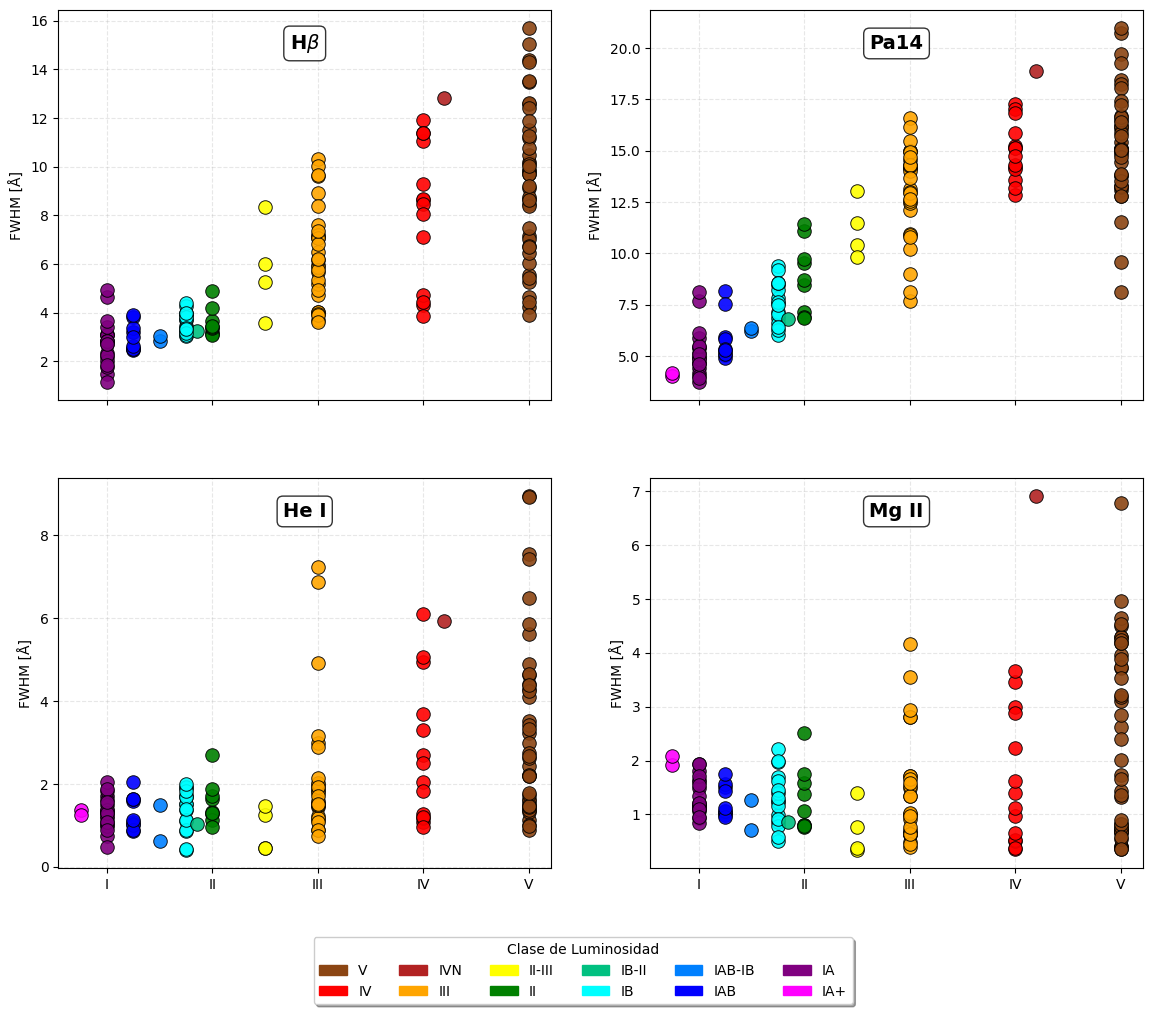

In [51]:
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import re

# 1. Configuración de rutas
PATH_ANALISIS = r"C:\Users\User\Documents\TFG\Análisis"

# 2. DICCIONARIO
star_data_raw = {
    "HD37128":  {"SpC": "B0 Ia", "vsini": 52}, "HD205196": {"SpC": "B0 Ib", "vsini": 51},
    "HD164402": {"SpC": "B0 Ib", "vsini": 54}, "HD48434":  {"SpC": "B0 III", "vsini": 52},
    "HD149438": {"SpC": "B0 V", "vsini": 9}, "HD171012": {"SpC": "B0.2 Ia", "vsini": 66},
    "HD204172": {"SpC": "B0.2 Iab", "vsini": 58}, "HD16808":  {"SpC": "B0.2 Ib", "vsini": 78},
    "HD6675":   {"SpC": "B0.2 III", "vsini": 29}, "HD36822":  {"SpC": "B0.2 IV", "vsini": 19},
    "HD2083":   {"SpC": "B0.2 V", "vsini": 11}, "HD38771":  {"SpC": "B0.5 Ia", "vsini": 47},
    "HD194839": {"SpC": "B0.5 Ia", "vsini": 65}, "HD192422": {"SpC": "B0.5 Ib", "vsini": 50},
    "HD213087": {"SpC": "B0.5 Ib", "vsini": 64}, "HD193007": {"SpC": "B0.5 II", "vsini": 61},
    "HD218376": {"SpC": "B0.5 III", "vsini": 29}, "HD36960":  {"SpC": "B0.5 V", "vsini": 25},
    "HD216411": {"SpC": "B0.7 Ia", "vsini": 60}, "HD2905":   {"SpC": "BC0.7 Ia", "vsini": 59},
    "HD190066": {"SpC": "B0.7 Ib", "vsini": 60}, "HD190919": {"SpC": "B0.7 II", "vsini": 43},
    "HD193076": {"SpC": "B0.7 II", "vsini": 60}, "HD14053":  {"SpC": "B0.7 II", "vsini": 23},
    "HD13969":  {"SpC": "B0.7 III", "vsini": 36}, "HD37042":  {"SpC": "B0.7 V", "vsini": 33},
    "HD201795": {"SpC": "B0.7 V", "vsini": 8}, "HD169454": {"SpC": "B1 Ia+", "vsini": 47},
    "HD13256":  {"SpC": "B1 Ia", "vsini": 45}, "HD13854":  {"SpC": "B1 Iab", "vsini": 55},
    "HD91316":  {"SpC": "B1 Iab Ns", "vsini": 47}, "HD24398":  {"SpC": "B1 Ib", "vsini": 39},
    "HD44743":  {"SpC": "B1 II-III", "vsini": 26}, "HD144470": {"SpC": "B1 V", "vsini": 104},
    "HD24131":  {"SpC": "B1 V", "vsini": 80}, "HD190603": {"SpC": "B1.5 Ia+", "vsini": 53},
    "HD14956":  {"SpC": "B1.5 Ia", "vsini": 52}, "HD5551":   {"SpC": "B1.5 Iab", "vsini": 57},
    "HD193183": {"SpC": "B1.5 Ib", "vsini": 50}, "HD13841":  {"SpC": "B1.5 Ib", "vsini": 43},
    "HD52089":  {"SpC": "B1.5 II", "vsini": 26}, "HD214993": {"SpC": "B1.5 III", "vsini": 25},
    "HD215191": {"SpC": "B1.5 V", "vsini": 205}, "HD35299":  {"SpC": "B1.5 V", "vsini": 6},
    "HD37744":  {"SpC": "B1.5 V", "vsini": 37}, "HD41117":  {"SpC": "B2 Ia", "vsini": 47},
    "HD14143":  {"SpC": "B2 Ia", "vsini": 55}, "HD15690":  {"SpC": "B2 Iab-Ib", "vsini": 46},
    "HD206165": {"SpC": "B2 Ib", "vsini": 41}, "HD31327":  {"SpC": "B2 II", "vsini": 31},
    "HD30836":  {"SpC": "B2 III", "vsini": 37}, "HD35468":  {"SpC": "B2 III", "vsini": 53},
    "HD886":    {"SpC": "B2 IV", "vsini": 8}, "HD3360":    {"SpC": "B2 IV", "vsini": 22},
    "HD36285":  {"SpC": "B2 V", "vsini": 12}, "HD36629":  {"SpC": "B2 V", "vsini": 9},
    "HD144218": {"SpC": "B2 V", "vsini": 57}, "HD208947": {"SpC": "B2 V", "vsini": 25},
    "HD198478": {"SpC": "B2.5 Ia", "vsini": 36}, "HD42087":  {"SpC": "B2.5 Ib", "vsini": 39},
    "HD207330": {"SpC": "B2.5 III", "vsini": 38}, "HD148605": {"SpC": "B2.5 V", "vsini": 167},
    "HD175191": {"SpC": "B2.5 V", "vsini": 122}, "HD14134":  {"SpC": "B3 Ia", "vsini": 37},
    "HD53138":  {"SpC": "B3 Ia", "vsini": 36}, "HD51309":  {"SpC": "B3 Ib", "vsini": 21},
    "HD36212":  {"SpC": "B3 II", "vsini": 17}, "HD194779": {"SpC": "B3 II", "vsini": 120},
    "HD21483":  {"SpC": "B3 III", "vsini": 131}, "HD49567":  {"SpC": "B3 III", "vsini": 4},
    "HD3901":   {"SpC": "B3 IV", "vsini": 113}, "HD160762": {"SpC": "B3 IV", "vsini": 6},
    "HD20365":  {"SpC": "B3 V", "vsini": 131}, "HD32630":  {"SpC": "B3 V", "vsini": 85},
    "HD120315": {"SpC": "B3 V", "vsini": 161}, "HD178849": {"SpC": "B3 V", "vsini": 36},
    "HD36371":  {"SpC": "B4 Ia", "vsini": 32}, "HD164353": {"SpC": "B4 Ib-II", "vsini": 22},
    "HD41692":  {"SpC": "B4 III", "vsini": 31}, "HD180554": {"SpC": "B4 IV", "vsini": 30},
    "HD26739":  {"SpC": "B4 V", "vsini": 35}, "HD34759":  {"SpC": "B4 V", "vsini": 62},
    "HD58350":  {"SpC": "B5 Ia", "vsini": 32}, "HD7902":    {"SpC": "B5 Iab", "vsini": 33},
    "HD9311":   {"SpC": "B5 Ib", "vsini": 24}, "HD191243": {"SpC": "B5 II", "vsini": 26},
    "HD170682": {"SpC": "B5 III", "vsini": 120}, "HD211924": {"SpC": "B5 III", "vsini": 27},
    "HD147394": {"SpC": "B5 V", "vsini": 32}, "HD4142":   {"SpC": "B5 V", "vsini": 199},
    "HD161572": {"SpC": "B5 V", "vsini": 186}, "HD36936":  {"SpC": "B5 V", "vsini": 219},
    "HD20809":  {"SpC": "B5 V", "vsini": 168}, "HD15497":  {"SpC": "B6 Ia", "vsini": 35},
    "HD17145":  {"SpC": "B6 Iab", "vsini": 33}, "HD170719": {"SpC": "B6 III", "vsini": 28},
    "HD34503":  {"SpC": "B6 III", "vsini": 35}, "HD49340":  {"SpC": "B6 III", "vsini": 184},
    "HD23338":  {"SpC": "B6 IV", "vsini": 111}, "HD90994":  {"SpC": "B6 V", "vsini": 83},
    "HD183143": {"SpC": "B7 Ia", "vsini": 42}, "HD199478": {"SpC": "B7 Ia", "vsini": 37},
    "HD208501": {"SpC": "B7 Iab", "vsini": 39}, "HD35497":  {"SpC": "B7 III", "vsini": 60},
    "HD23408":  {"SpC": "B7 III", "vsini": 32}, "HD1279":   {"SpC": "B7 III", "vsini": 29},
    "HD23288":  {"SpC": "B7 V", "vsini": 202}, "HD21071":  {"SpC": "B7 V", "vsini": 66},
    "HD182255": {"SpC": "B7 V", "vsini": 30}, "HD34085":  {"SpC": "B8 Ia", "vsini": 32},
    "HD14542":  {"SpC": "B8 Iab", "vsini": 29}, "HD12301":  {"SpC": "B8 Ib", "vsini": 24},
    "HD23850":  {"SpC": "B8 III", "vsini": 230}, "HD155763": {"SpC": "B8 III", "vsini": 43},
    "HD179761": {"SpC": "B8 III", "vsini": 15}, "HD10205":  {"SpC": "B8 III", "vsini": 89},
    "HD17081":  {"SpC": "B8 IV", "vsini": 19}, "HD87901":  {"SpC": "B8 IVn", "vsini": 306},
    "HD3240":   {"SpC": "B8 IV", "vsini": 69}, "HD46075":  {"SpC": "B8 IV", "vsini": 53},
    "HD23324":  {"SpC": "B8 V", "vsini": 212}, "HD23432":  {"SpC": "B8 V", "vsini": 160},
    "HD21672":  {"SpC": "B8 V", "vsini": 250}, "HD171301": {"SpC": "B8 V", "vsini": 33},
    "HD224112": {"SpC": "B8 V", "vsini": 40}, "HD184943": {"SpC": "B8.5 Iab", "vsini": 37},
    "HD214923": {"SpC": "B8.5 IV", "vsini": 160}, "HD21279":  {"SpC": "B8.5 V", "vsini": 198},
    "HD23923":  {"SpC": "B8.5 V", "vsini": 308}, "HD21291":  {"SpC": "B9 Ia", "vsini": 32},
    "HD223960": {"SpC": "B9 Ia", "vsini": 32}, "HD202850": {"SpC": "B9 Iab", "vsini": 31},
    "HD212593": {"SpC": "B9 Iab-Ib", "vsini": 23}, "HD35600":  {"SpC": "B9 Ib", "vsini": 31},
    "HD21661":  {"SpC": "B9 II-III", "vsini": 5}, "HD57608":  {"SpC": "B9 II-III", "vsini": 10},
    "HD212097": {"SpC": "B9 III", "vsini": 70}, "HD2011":   {"SpC": "B9 III", "vsini": 125},
    "HD51688":  {"SpC": "B9 III", "vsini": 32}, "HD49606":  {"SpC": "B9 III", "vsini": 20},
    "HD196867": {"SpC": "B9 IV", "vsini": 108}, "HD21931":  {"SpC": "B9 V", "vsini": 161},
    "HD38899":  {"SpC": "B9 V", "vsini": 25}, "HD176437": {"SpC": "B9.5 II-III", "vsini": 74},
    "HD181440": {"SpC": "B9.5 III", "vsini": 55}, "HD144206": {"SpC": "B9.5 III", "vsini": 10},
    "HD186882": {"SpC": "B9.5 IV", "vsini": 158}, "HD16046":  {"SpC": "B9.5 IV", "vsini": 44},
    "HD23873":  {"SpC": "B9.5 V", "vsini": 85}, "HD23568":  {"SpC": "B9.5 V", "vsini": 181},
    "HD222661": {"SpC": "B9.5 V", "vsini": 136}, "HD21389":  {"SpC": "A0 Ia", "vsini": 37},
    "HD46300":  {"SpC": "A0 Ib", "vsini": 7}, "HD87737":  {"SpC": "A0 Ib", "vsini": 10},
    "HD123299": {"SpC": "A0 III", "vsini": 26}, "HD103287": {"SpC": "A0 V", "vsini": 177},
    "HD172167": {"SpC": "A0 V", "vsini": 22}, "HD197345": {"SpC": "A2 Ia", "vsini": 26}
}

star_data = {str(k).strip().replace(" ", "").upper(): v for k, v in star_data_raw.items()}

# 3. Colores y Lógica de Luminosidad
lum_colors_map = {
    "V": "#8B4513", "IV": "#FF0000", "IVN": "#B22222", "III": "#FFA500",
    "II-III": "#FFFF00", "II": "#008000", "IB-II": "#00C080", "IB": "#00FFFF",
    "IAB-IB": "#0080FF", "IAB": "#0000FF", "IA": "#800080", "IA+": "#FF00FF"
}
orden_logico = ["V", "IV", "IVN", "III", "II-III", "II", "IB-II", "IB", "IAB-IB", "IAB", "IA", "IA+"]

def get_lum_info(spc_string):
    mapping_x = {"IA+":0.75, "IA":1.0, "IAB":1.25, "IAB-IB":1.5, "IB":1.75, "IB-II":1.85, "II":2.0, "II-III":2.5, "III":3.0, "IV":4.0, "IVN":4.2, "V":5.0}
    clean_spc = str(spc_string).upper().replace(":", "").strip()
    for key in sorted(mapping_x.keys(), key=len, reverse=True):
        if re.search(rf"\b{re.escape(key)}\b", clean_spc) or clean_spc.endswith(key):
            return mapping_x[key], key
    return None, None

# 4. Configuración de Layout y Gráficos
# He añadido el nombre de la línea a la configuración
layout_config = {
    4860: (0,0, r"H$\beta$"), 
    8598: (0,1, "Pa14"), 
    4387: (1,0, "He I"), 
    4481: (1,1, "Mg II")
}
fig, axes = plt.subplots(2, 2, figsize=(14, 11), sharex=True)

estrellas_en_ficheros = set()
estrellas_graficadas_exito = set()
razones_fallo = {}

# 5. PROCESAMIENTO
files = sorted([f for f in os.listdir(PATH_ANALISIS) if f.endswith('.csv')])

print("\n--- PROCESAMIENTO DE ARCHIVOS ---")

for file_name in files:
    match = re.search(r'\d+', file_name)
    if not match: continue
    wvl = int(match.group())
    if wvl not in layout_config: continue
    
    row_idx, col_idx, line_label = layout_config[wvl]
    ax = axes[row_idx, col_idx]
    file_path = os.path.join(PATH_ANALISIS, file_name)
    
    # --- NUEVA PARTE: ETIQUETA EN LA GRÁFICA ---
    # Coloca el nombre de la línea en un recuadro blanco arriba al centro
    ax.text(0.5, 0.9, line_label, transform=ax.transAxes, 
            fontsize=14, fontweight='bold', ha='center',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', boxstyle='round,pad=0.3'))
    
    count_graficadas = 0
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = [p.strip() for p in line.replace(';', ',').split(',') if p.strip()]
            if len(parts) >= 3:
                nombre_raw = parts[0].upper().replace(" ", "")
                if "ESTRELLA" in nombre_raw: continue
                
                nombre_hd = nombre_raw if nombre_raw.startswith("HD") else "HD" + nombre_raw
                estrellas_en_ficheros.add(nombre_hd)
                
                if nombre_hd in star_data:
                    try:
                        fwhm = float(parts[2])
                        val_x, label_lum = get_lum_info(star_data[nombre_hd]["SpC"])
                        if val_x is not None:
                            color = lum_colors_map.get(label_lum, "#808080")
                            ax.scatter(val_x, fwhm, color=color, edgecolors='black', 
                                    s=95, alpha=0.9, zorder=3, linewidths=0.7)
                            count_graficadas += 1
                            estrellas_graficadas_exito.add(nombre_hd)
                        else:
                            razones_fallo[nombre_hd] = f"Tipo '{star_data[nombre_hd]['SpC']}' no reconocido"
                    except ValueError:
                        razones_fallo[nombre_hd] = "FWHM no numérico"
                else:
                    razones_fallo[nombre_hd] = "No está en star_data_raw"

    ax.set_ylabel("FWHM [Å]", fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.3)

# 6. Formateo de Ejes y Leyenda
for ax in axes.flat:
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.set_xticklabels(['I', 'II', 'III', 'IV', 'V'])

# Filtrar solo las luminosidades que realmente se graficaron para la leyenda
lums_en_grafica = set()
for e in estrellas_graficadas_exito:
    _, l = get_lum_info(star_data[e]["SpC"])
    if l: lums_en_grafica.add(l)

handles = [mpatches.Patch(color=lum_colors_map[l], label=l) for l in orden_logico if l in lums_en_grafica]

fig.legend(handles=handles, title="Clase de Luminosidad", loc='lower center', 
        ncol=6, bbox_to_anchor=(0.5, 0.02), frameon=True, shadow=True)

# Ajuste fino de espacios para que no se corten etiquetas ni la leyenda
plt.subplots_adjust(bottom=0.15, top=0.93, hspace=0.2, wspace=0.2)
plt.show()

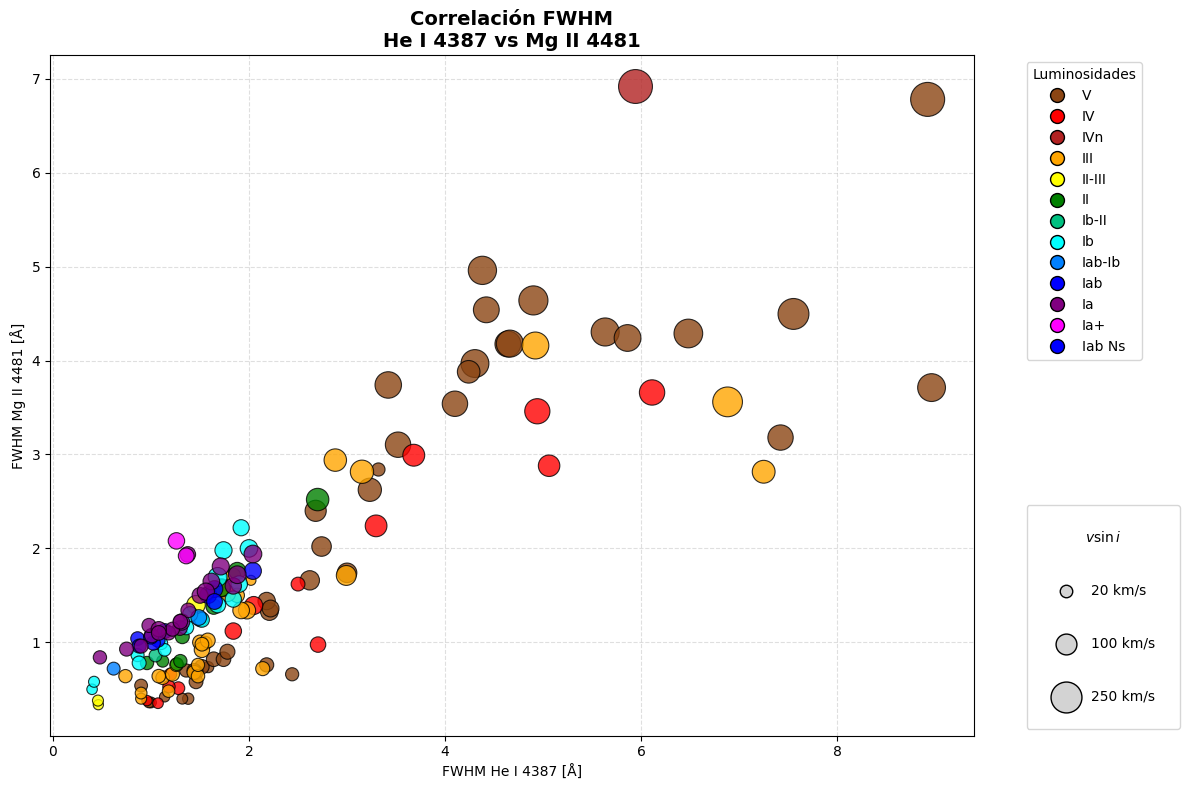

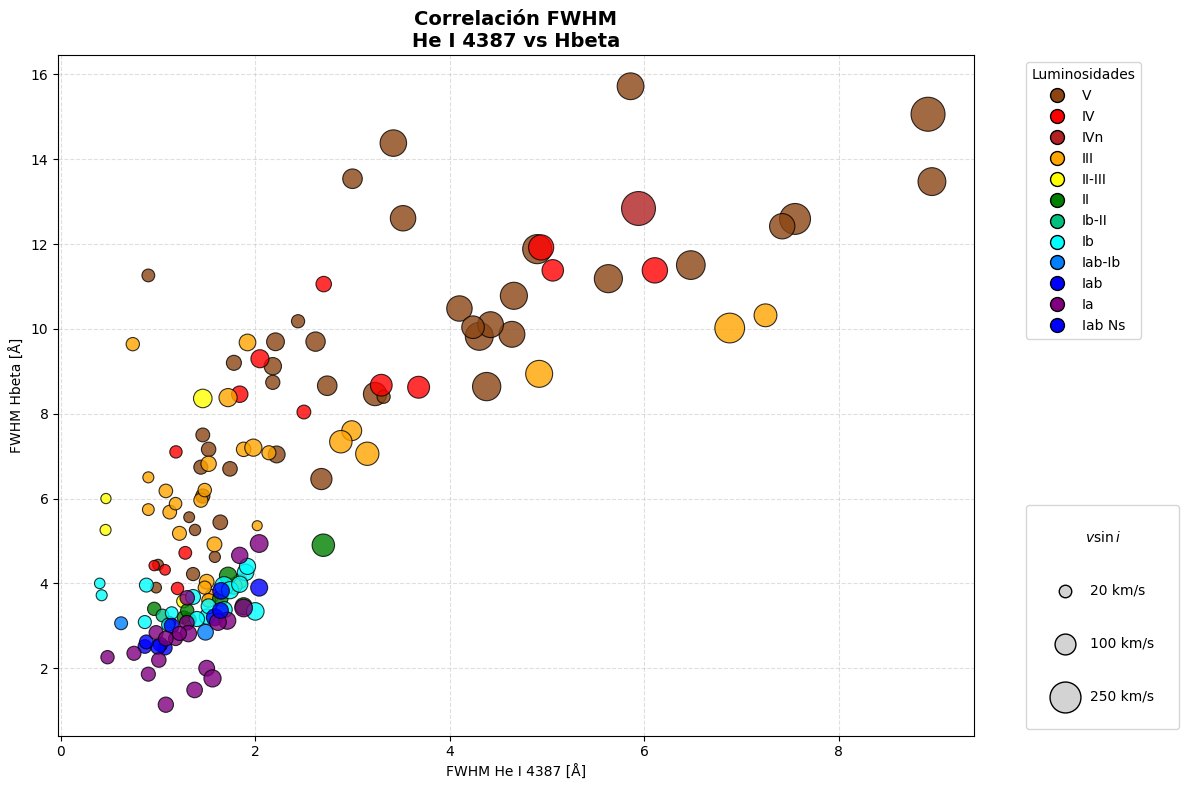

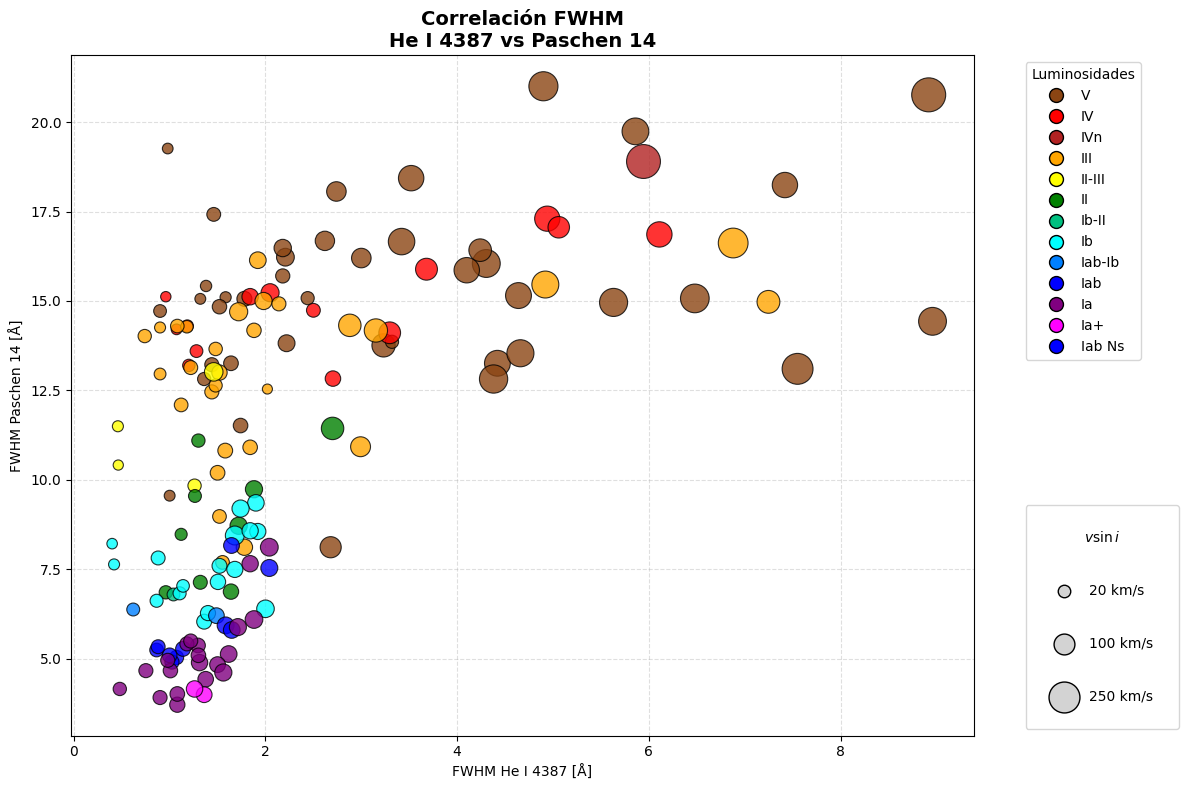

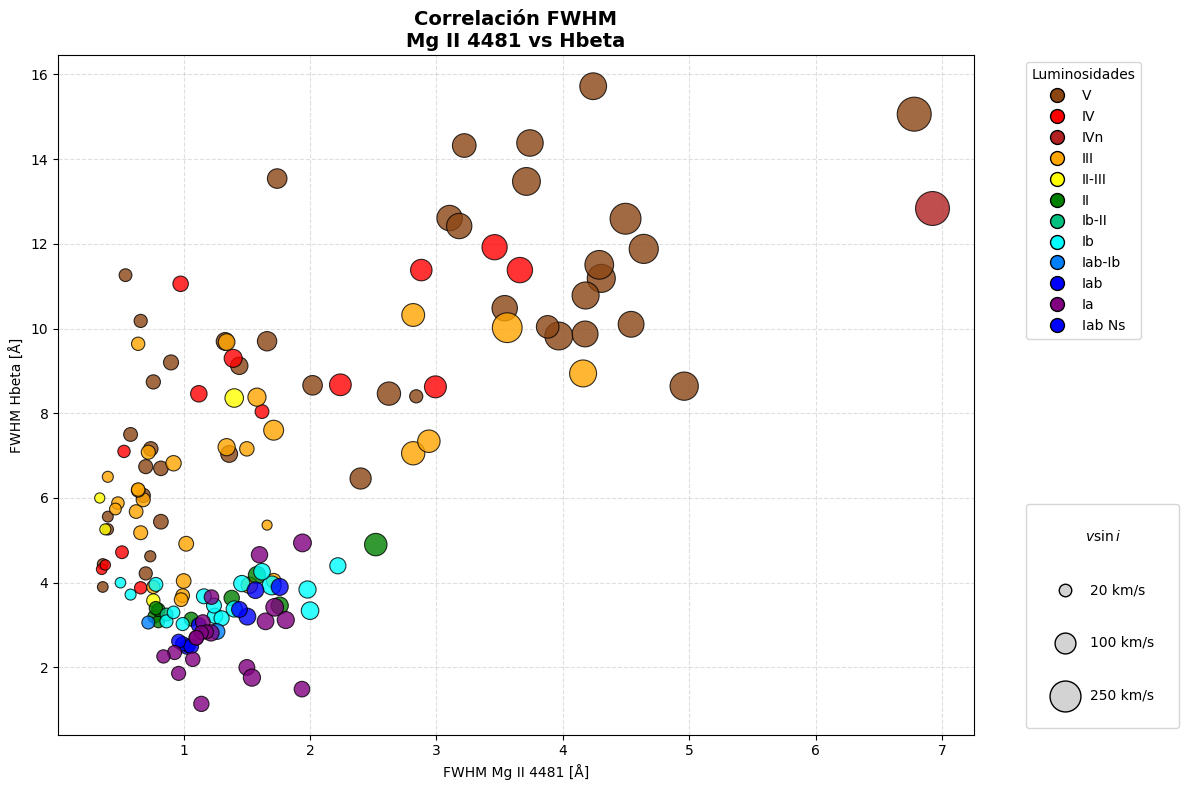

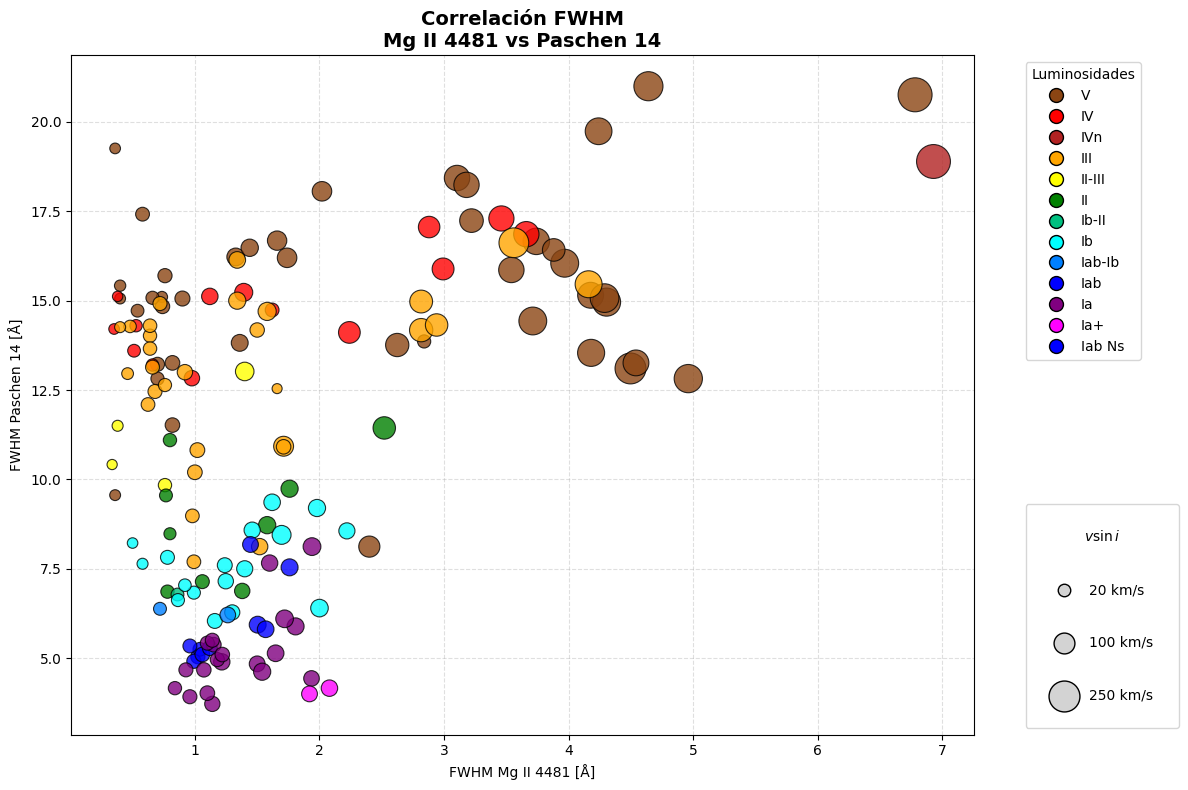

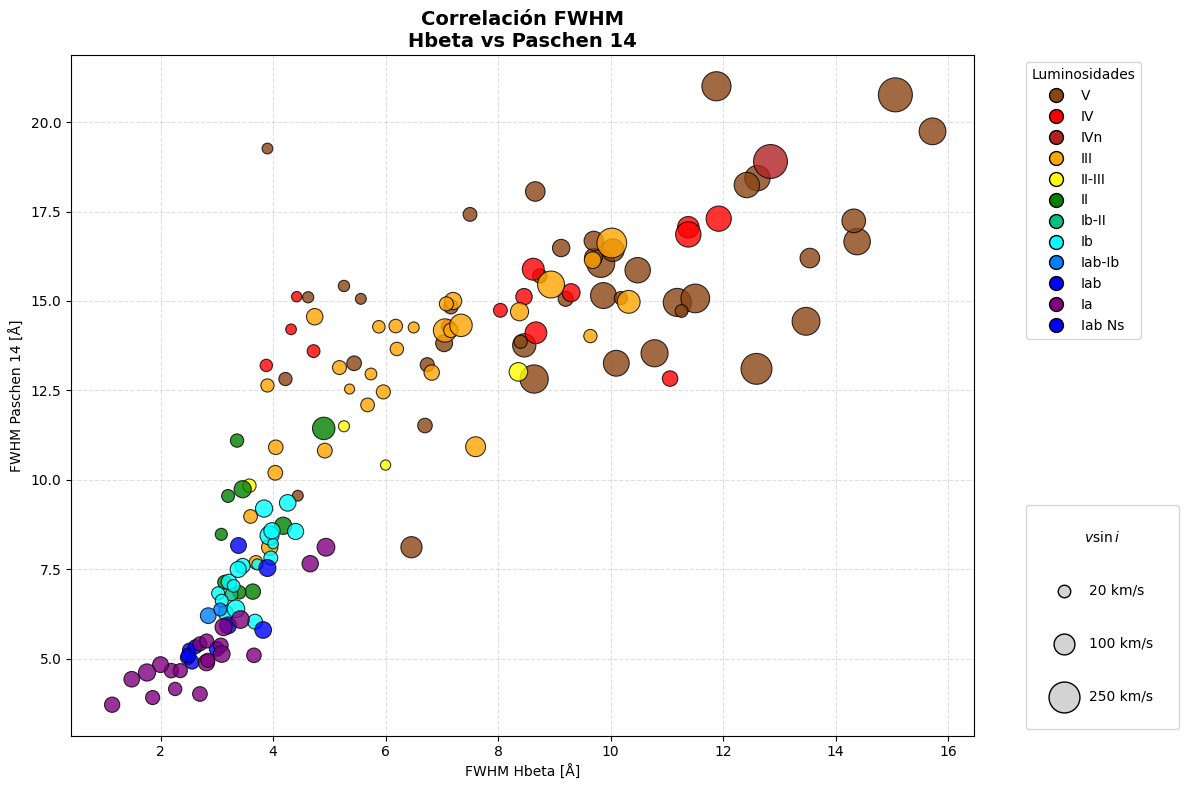


✨ Gráficas listas.


In [52]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import re

# 1. Configuración de rutas
PATH_ANALISIS = r"C:\Users\User\Documents\TFG\Análisis"

# 2. DICCIONARIO (Asegúrate de tener todos tus datos aquí)
star_data_raw = {
    "HD37128":  {"SpC": "B0 Ia", "vsini": 52}, "HD205196": {"SpC": "B0 Ib", "vsini": 51},
    "HD164402": {"SpC": "B0 Ib", "vsini": 54}, "HD48434":  {"SpC": "B0 III", "vsini": 52},
    "HD149438": {"SpC": "B0 V", "vsini": 9}, "HD171012": {"SpC": "B0.2 Ia", "vsini": 66},
    "HD204172": {"SpC": "B0.2 Iab", "vsini": 58}, "HD16808":  {"SpC": "B0.2 Ib", "vsini": 78},
    "HD6675":   {"SpC": "B0.2 III", "vsini": 29}, "HD36822":  {"SpC": "B0.2 IV", "vsini": 19},
    "HD2083":   {"SpC": "B0.2 V", "vsini": 11}, "HD38771":  {"SpC": "B0.5 Ia", "vsini": 47},
    "HD194839": {"SpC": "B0.5 Ia", "vsini": 65}, "HD192422": {"SpC": "B0.5 Ib", "vsini": 50},
    "HD213087": {"SpC": "B0.5 Ib", "vsini": 64}, "HD193007": {"SpC": "B0.5 II", "vsini": 61},
    "HD218376": {"SpC": "B0.5 III", "vsini": 29}, "HD36960":  {"SpC": "B0.5 V", "vsini": 25},
    "HD216411": {"SpC": "B0.7 Ia", "vsini": 60}, "HD2905":   {"SpC": "BC0.7 Ia", "vsini": 59},
    "HD190066": {"SpC": "B0.7 Ib", "vsini": 60}, "HD190919": {"SpC": "B0.7 II", "vsini": 43},
    "HD193076": {"SpC": "B0.7 II", "vsini": 60}, "HD14053":  {"SpC": "B0.7 II", "vsini": 23},
    "HD13969":  {"SpC": "B0.7 III", "vsini": 36}, "HD37042":  {"SpC": "B0.7 V", "vsini": 33},
    "HD201795": {"SpC": "B0.7 V", "vsini": 8}, "HD169454": {"SpC": "B1 Ia+", "vsini": 47},
    "HD13256":  {"SpC": "B1 Ia", "vsini": 45}, "HD13854":  {"SpC": "B1 Iab", "vsini": 55},
    "HD91316":  {"SpC": "B1 Iab Ns", "vsini": 47}, "HD24398":  {"SpC": "B1 Ib", "vsini": 39},
    "HD44743":  {"SpC": "B1 II-III", "vsini": 26}, "HD144470": {"SpC": "B1 V", "vsini": 104},
    "HD24131":  {"SpC": "B1 V", "vsini": 80}, "HD190603": {"SpC": "B1.5 Ia+", "vsini": 53},
    "HD14956":  {"SpC": "B1.5 Ia", "vsini": 52}, "HD5551":   {"SpC": "B1.5 Iab", "vsini": 57},
    "HD193183": {"SpC": "B1.5 Ib", "vsini": 50}, "HD13841":  {"SpC": "B1.5 Ib", "vsini": 43},
    "HD52089":  {"SpC": "B1.5 II", "vsini": 26}, "HD214993": {"SpC": "B1.5 III", "vsini": 25},
    "HD215191": {"SpC": "B1.5 V", "vsini": 205}, "HD35299":  {"SpC": "B1.5 V", "vsini": 6},
    "HD37744":  {"SpC": "B1.5 V", "vsini": 37}, "HD41117":  {"SpC": "B2 Ia", "vsini": 47},
    "HD14143":  {"SpC": "B2 Ia", "vsini": 55}, "HD15690":  {"SpC": "B2 Iab-Ib", "vsini": 46},
    "HD206165": {"SpC": "B2 Ib", "vsini": 41}, "HD31327":  {"SpC": "B2 II", "vsini": 31},
    "HD30836":  {"SpC": "B2 III", "vsini": 37}, "HD35468":  {"SpC": "B2 III", "vsini": 53},
    "HD886":    {"SpC": "B2 IV", "vsini": 8}, "HD3360":    {"SpC": "B2 IV", "vsini": 22},
    "HD36285":  {"SpC": "B2 V", "vsini": 12}, "HD36629":  {"SpC": "B2 V", "vsini": 9},
    "HD144218": {"SpC": "B2 V", "vsini": 57}, "HD208947": {"SpC": "B2 V", "vsini": 25},
    "HD198478": {"SpC": "B2.5 Ia", "vsini": 36}, "HD42087":  {"SpC": "B2.5 Ib", "vsini": 39},
    "HD207330": {"SpC": "B2.5 III", "vsini": 38}, "HD148605": {"SpC": "B2.5 V", "vsini": 167},
    "HD175191": {"SpC": "B2.5 V", "vsini": 122}, "HD14134":  {"SpC": "B3 Ia", "vsini": 37},
    "HD53138":  {"SpC": "B3 Ia", "vsini": 36}, "HD51309":  {"SpC": "B3 Ib", "vsini": 21},
    "HD36212":  {"SpC": "B3 II", "vsini": 17}, "HD194779": {"SpC": "B3 II", "vsini": 120},
    "HD21483":  {"SpC": "B3 III", "vsini": 131}, "HD49567":  {"SpC": "B3 III", "vsini": 4},
    "HD3901":   {"SpC": "B3 IV", "vsini": 113}, "HD160762": {"SpC": "B3 IV", "vsini": 6},
    "HD20365":  {"SpC": "B3 V", "vsini": 131}, "HD32630":  {"SpC": "B3 V", "vsini": 85},
    "HD120315": {"SpC": "B3 V", "vsini": 161}, "HD178849": {"SpC": "B3 V", "vsini": 36},
    "HD36371":  {"SpC": "B4 Ia", "vsini": 32}, "HD164353": {"SpC": "B4 Ib-II", "vsini": 22},
    "HD41692":  {"SpC": "B4 III", "vsini": 31}, "HD180554": {"SpC": "B4 IV", "vsini": 30},
    "HD26739":  {"SpC": "B4 V", "vsini": 35}, "HD34759":  {"SpC": "B4 V", "vsini": 62},
    "HD58350":  {"SpC": "B5 Ia", "vsini": 32}, "HD7902":    {"SpC": "B5 Iab", "vsini": 33},
    "HD9311":   {"SpC": "B5 Ib", "vsini": 24}, "HD191243": {"SpC": "B5 II", "vsini": 26},
    "HD170682": {"SpC": "B5 III", "vsini": 120}, "HD211924": {"SpC": "B5 III", "vsini": 27},
    "HD147394": {"SpC": "B5 V", "vsini": 32}, "HD4142":   {"SpC": "B5 V", "vsini": 199},
    "HD161572": {"SpC": "B5 V", "vsini": 186}, "HD36936":  {"SpC": "B5 V", "vsini": 219},
    "HD20809":  {"SpC": "B5 V", "vsini": 168}, "HD15497":  {"SpC": "B6 Ia", "vsini": 35},
    "HD17145":  {"SpC": "B6 Iab", "vsini": 33}, "HD170719": {"SpC": "B6 III", "vsini": 28},
    "HD34503":  {"SpC": "B6 III", "vsini": 35}, "HD49340":  {"SpC": "B6 III", "vsini": 184},
    "HD23338":  {"SpC": "B6 IV", "vsini": 111}, "HD90994":  {"SpC": "B6 V", "vsini": 83},
    "HD183143": {"SpC": "B7 Ia", "vsini": 42}, "HD199478": {"SpC": "B7 Ia", "vsini": 37},
    "HD208501": {"SpC": "B7 Iab", "vsini": 39}, "HD35497":  {"SpC": "B7 III", "vsini": 60},
    "HD23408":  {"SpC": "B7 III", "vsini": 32}, "HD1279":   {"SpC": "B7 III", "vsini": 29},
    "HD23288":  {"SpC": "B7 V", "vsini": 202}, "HD21071":  {"SpC": "B7 V", "vsini": 66},
    "HD182255": {"SpC": "B7 V", "vsini": 30}, "HD34085":  {"SpC": "B8 Ia", "vsini": 32},
    "HD14542":  {"SpC": "B8 Iab", "vsini": 29}, "HD12301":  {"SpC": "B8 Ib", "vsini": 24},
    "HD23850":  {"SpC": "B8 III", "vsini": 230}, "HD155763": {"SpC": "B8 III", "vsini": 43},
    "HD179761": {"SpC": "B8 III", "vsini": 15}, "HD10205":  {"SpC": "B8 III", "vsini": 89},
    "HD17081":  {"SpC": "B8 IV", "vsini": 19}, "HD87901":  {"SpC": "B8 IVn", "vsini": 306},
    "HD3240":   {"SpC": "B8 IV", "vsini": 69}, "HD46075":  {"SpC": "B8 IV", "vsini": 53},
    "HD23324":  {"SpC": "B8 V", "vsini": 212}, "HD23432":  {"SpC": "B8 V", "vsini": 160},
    "HD21672":  {"SpC": "B8 V", "vsini": 250}, "HD171301": {"SpC": "B8 V", "vsini": 33},
    "HD224112": {"SpC": "B8 V", "vsini": 40}, "HD184943": {"SpC": "B8.5 Iab", "vsini": 37},
    "HD214923": {"SpC": "B8.5 IV", "vsini": 160}, "HD21279":  {"SpC": "B8.5 V", "vsini": 198},
    "HD23923":  {"SpC": "B8.5 V", "vsini": 308}, "HD21291":  {"SpC": "B9 Ia", "vsini": 32},
    "HD223960": {"SpC": "B9 Ia", "vsini": 32}, "HD202850": {"SpC": "B9 Iab", "vsini": 31},
    "HD212593": {"SpC": "B9 Iab-Ib", "vsini": 23}, "HD35600":  {"SpC": "B9 Ib", "vsini": 31},
    "HD21661":  {"SpC": "B9 II-III", "vsini": 5}, "HD57608":  {"SpC": "B9 II-III", "vsini": 10},
    "HD212097": {"SpC": "B9 III", "vsini": 70}, "HD2011":   {"SpC": "B9 III", "vsini": 125},
    "HD51688":  {"SpC": "B9 III", "vsini": 32}, "HD49606":  {"SpC": "B9 III", "vsini": 20},
    "HD196867": {"SpC": "B9 IV", "vsini": 108}, "HD21931":  {"SpC": "B9 V", "vsini": 161},
    "HD38899":  {"SpC": "B9 V", "vsini": 25}, "HD176437": {"SpC": "B9.5 II-III", "vsini": 74},
    "HD181440": {"SpC": "B9.5 III", "vsini": 55}, "HD144206": {"SpC": "B9.5 III", "vsini": 10},
    "HD186882": {"SpC": "B9.5 IV", "vsini": 158}, "HD16046":  {"SpC": "B9.5 IV", "vsini": 44},
    "HD23873":  {"SpC": "B9.5 V", "vsini": 85}, "HD23568":  {"SpC": "B9.5 V", "vsini": 181},
    "HD222661": {"SpC": "B9.5 V", "vsini": 136}, "HD21389":  {"SpC": "A0 Ia", "vsini": 37},
    "HD46300":  {"SpC": "A0 Ib", "vsini": 7}, "HD87737":  {"SpC": "A0 Ib", "vsini": 10},
    "HD123299": {"SpC": "A0 III", "vsini": 26}, "HD103287": {"SpC": "A0 V", "vsini": 177},
    "HD172167": {"SpC": "A0 V", "vsini": 22}, "HD197345": {"SpC": "A2 Ia", "vsini": 26}
}

star_data = {k.strip().upper(): v for k, v in star_data_raw.items()}

# 3. Estética: COLORES PERSONALIZADOS y ORDEN LÓGICO
orden_logico = ["V", "IV", "IVn", "III", "II-III", "II", "Ib-II", "Ib", "Iab-Ib", "Iab", "Ia", "Ia+"]

lum_colors_map = {
    "V": "#8B4513",        # Marrón (SaddleBrown)
    "IV": "#FF0000",       # Rojo
    "IVn": "#B22222",      # Rojo fuego oscuro (para variantes IV)
    "III": "#FFA500",      # Naranja
    "II-III": "#FFFF00",   # Amarillo
    "II": "#008000",       # Verde
    "Ib-II": "#00C080",    # Turquesa/Verde azulado
    "Ib": "#00FFFF",       # Cian
    "Iab-Ib": "#0080FF",   # Azul cielo profundo
    "Iab": "#0000FF",      # Azul Rey
    "Ia": "#800080",       # Púrpura
    "Ia+": "#FF00FF"       # Magenta
}

def obtener_nombre_linea(nombre_archivo):
    match = re.search(r'\d+', nombre_archivo)
    wvl = int(match.group()) if match else 0
    lineas = {4481: "Mg II 4481", 4387: "He I 4387", 4860: "Hbeta", 8598: "Paschen 14"}
    return lineas.get(wvl, f"Línea {wvl} Å")

# 4. Procesamiento
files = sorted([f for f in os.listdir(PATH_ANALISIS) if f.endswith('.csv')])
all_lines_data = {}

for file_name in files:
    file_path = os.path.join(PATH_ANALISIS, file_name)
    line_dict = {}
    with open(file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        for line in lines[1:]:
            parts = line.strip().split(',')
            if len(parts) >= 3:
                nombre = parts[0].strip().replace(' ', '').upper()
                if nombre in star_data:
                    line_dict[nombre] = float(parts[2])
    if line_dict:
        all_lines_data[file_name] = line_dict

line_names = list(all_lines_data.keys())

for i in range(len(line_names)):
    for j in range(i + 1, len(line_names)):
        file_a, file_b = line_names[i], line_names[j]
        label_a, label_b = obtener_nombre_linea(file_a), obtener_nombre_linea(file_b)
        
        comparacion_list = []
        for star, fwhm_a in all_lines_data[file_a].items():
            if star in all_lines_data[file_b]:
                info = star_data[star]
                spc_parts = info["SpC"].split()
                lum_full = " ".join(spc_parts[1:]) 
                comparacion_list.append({
                    'FWHM_A': fwhm_a, 'FWHM_B': all_lines_data[file_b][star],
                    'Lum_Full': lum_full, 'vsini': info["vsini"]
                })
        
        if comparacion_list:
            df_comp = pd.DataFrame(comparacion_list)
            plt.figure(figsize=(12, 8))
            
            # Ordenación de la leyenda
            present_lums = df_comp['Lum_Full'].unique()
            sorted_lums = [l for l in orden_logico if l in present_lums]
            sorted_lums += [l for l in present_lums if l not in orden_logico]

            main_handles = []
            for lum in sorted_lums:
                sub = df_comp[df_comp['Lum_Full'] == lum]
                color = lum_colors_map.get(lum, "#808080")
                if color == "#808080":
                    for key, val in lum_colors_map.items():
                        if key in lum: color = val; break
                
                # GRÁFICA: Tamaño variable
                sizes = 45 + (sub['vsini'] * 1.8)
                plt.scatter(sub['FWHM_A'], sub['FWHM_B'], color=color, 
                            edgecolors='black', s=sizes, zorder=3, alpha=0.8, linewidths=0.8)
                
                # LEYENDA LUMINOSIDAD: Tamaño fijo (Proxy)
                proxy = plt.Line2D([0], [0], marker='o', color='w', label=lum,
                                markerfacecolor=color, markersize=10, 
                                markeredgecolor='black', linestyle='None')
                main_handles.append(proxy)
            
            plt.title(f"Correlación FWHM\n{label_a} vs {label_b}", fontsize=14, fontweight='bold')
            plt.xlabel(f"FWHM {label_a} [Å]")
            plt.ylabel(f"FWHM {label_b} [Å]")
            
            # Leyenda 1: Luminosidades Ordenadas (V -> Ia)
            leg1 = plt.legend(handles=main_handles, title="Luminosidades", 
                            bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
            plt.gca().add_artist(leg1)
            
            # Leyenda 2: Velocidades con espaciado
            v_refs = [20, 100, 250]
            size_refs = [plt.scatter([], [], s=45 + (v*1.8), color='lightgray', 
                        edgecolors='black', label=f'{v} km/s') for v in v_refs]
            
            plt.legend(handles=size_refs, title="$v \sin i$", 
                    bbox_to_anchor=(1.05, 0), loc='lower left', 
                    frameon=True, labelspacing=2.8, borderpad=1.8)

            plt.grid(True, linestyle='--', alpha=0.4, zorder=0)
            plt.tight_layout()
            plt.show()

print("\n✨ Gráficas listas.")

#COMPROBAR CON ESTRELLA HD21661 (AMARILLA)

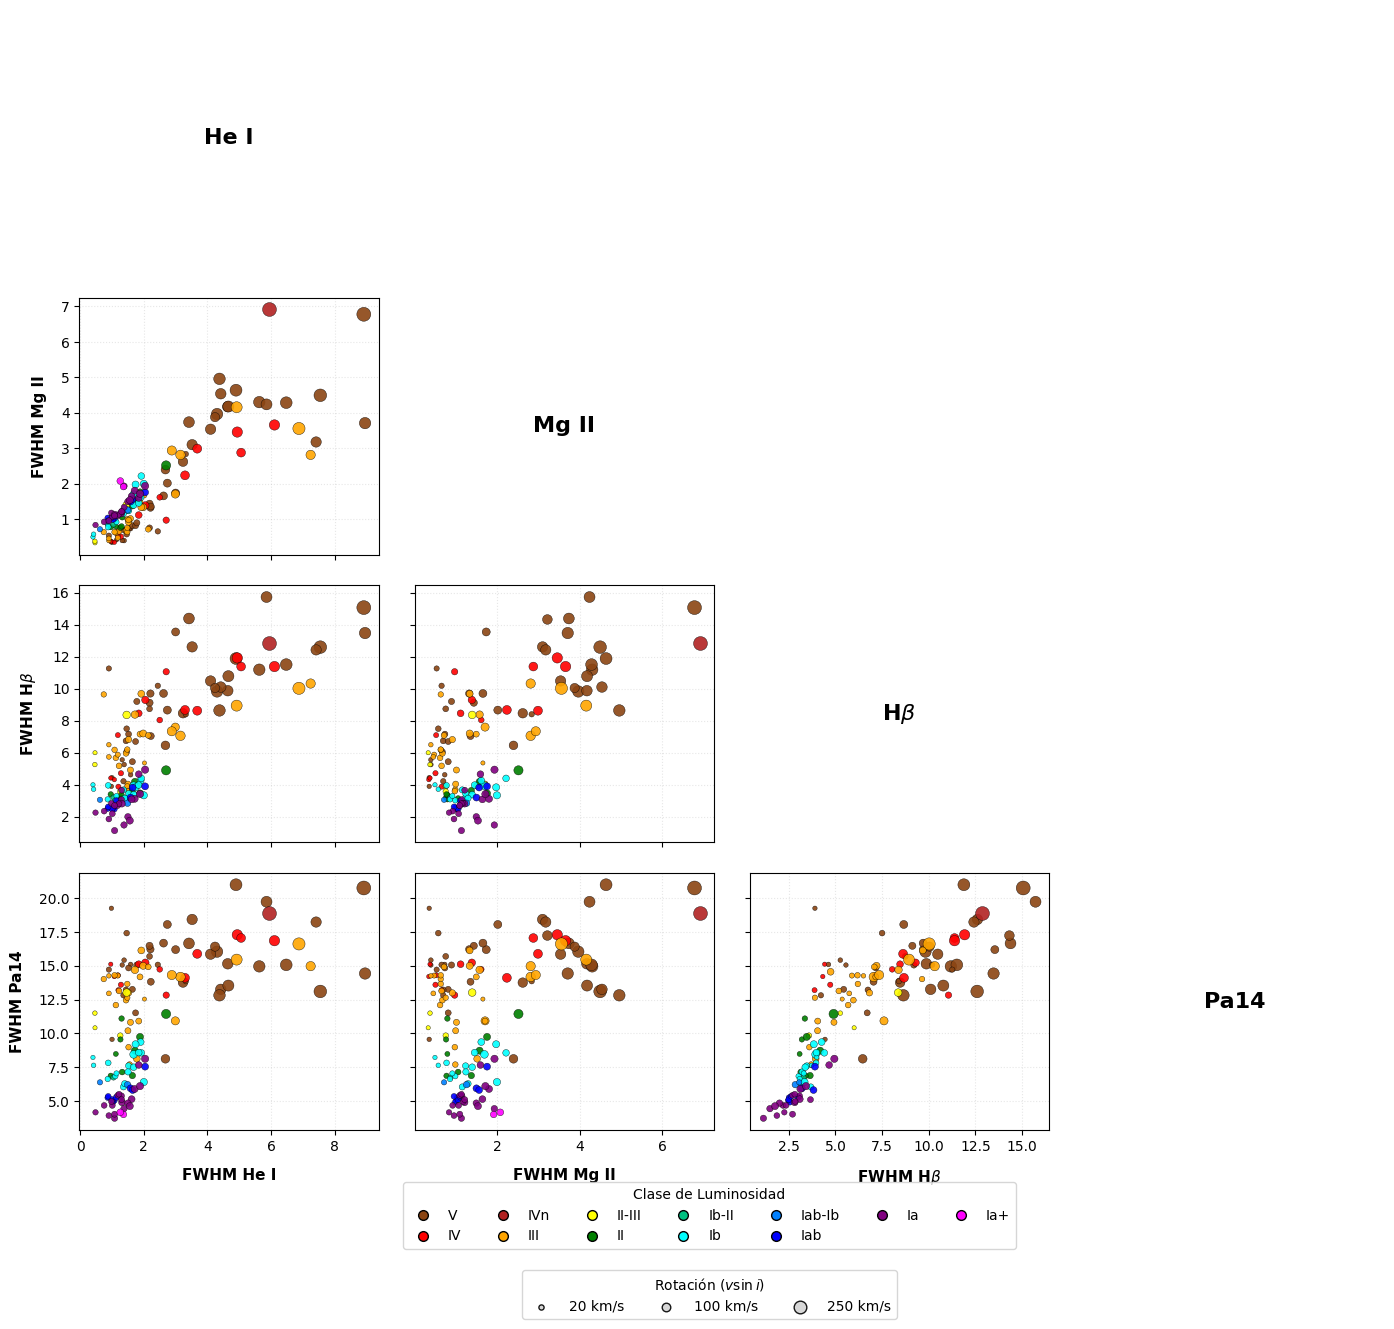

In [53]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import re

# --- 1. CONFIGURACIÓN DE RUTAS ---
PATH_ANALISIS = r"C:\Users\User\Documents\TFG\Análisis"

# --- 2. DICCIONARIO ---
star_data_raw = {
    "HD37128":  {"SpC": "B0 Ia", "vsini": 52}, "HD205196": {"SpC": "B0 Ib", "vsini": 51},
    "HD164402": {"SpC": "B0 Ib", "vsini": 54}, "HD48434":  {"SpC": "B0 III", "vsini": 52},
    "HD149438": {"SpC": "B0 V", "vsini": 9}, "HD171012": {"SpC": "B0.2 Ia", "vsini": 66},
    "HD204172": {"SpC": "B0.2 Iab", "vsini": 58}, "HD16808":  {"SpC": "B0.2 Ib", "vsini": 78},
    "HD6675":   {"SpC": "B0.2 III", "vsini": 29}, "HD36822":  {"SpC": "B0.2 IV", "vsini": 19},
    "HD2083":   {"SpC": "B0.2 V", "vsini": 11}, "HD38771":  {"SpC": "B0.5 Ia", "vsini": 47},
    "HD194839": {"SpC": "B0.5 Ia", "vsini": 65}, "HD192422": {"SpC": "B0.5 Ib", "vsini": 50},
    "HD213087": {"SpC": "B0.5 Ib", "vsini": 64}, "HD193007": {"SpC": "B0.5 II", "vsini": 61},
    "HD218376": {"SpC": "B0.5 III", "vsini": 29}, "HD36960":  {"SpC": "B0.5 V", "vsini": 25},
    "HD216411": {"SpC": "B0.7 Ia", "vsini": 60}, "HD2905":   {"SpC": "BC0.7 Ia", "vsini": 59},
    "HD190066": {"SpC": "B0.7 Ib", "vsini": 60}, "HD190919": {"SpC": "B0.7 II", "vsini": 43},
    "HD193076": {"SpC": "B0.7 II", "vsini": 60}, "HD14053":  {"SpC": "B0.7 II", "vsini": 23},
    "HD13969":  {"SpC": "B0.7 III", "vsini": 36}, "HD37042":  {"SpC": "B0.7 V", "vsini": 33},
    "HD201795": {"SpC": "B0.7 V", "vsini": 8}, "HD169454": {"SpC": "B1 Ia+", "vsini": 47},
    "HD13256":  {"SpC": "B1 Ia", "vsini": 45}, "HD13854":  {"SpC": "B1 Iab", "vsini": 55},
    "HD91316":  {"SpC": "B1 Iab Ns", "vsini": 47}, "HD24398":  {"SpC": "B1 Ib", "vsini": 39},
    "HD44743":  {"SpC": "B1 II-III", "vsini": 26}, "HD144470": {"SpC": "B1 V", "vsini": 104},
    "HD24131":  {"SpC": "B1 V", "vsini": 80}, "HD190603": {"SpC": "B1.5 Ia+", "vsini": 53},
    "HD14956":  {"SpC": "B1.5 Ia", "vsini": 52}, "HD5551":   {"SpC": "B1.5 Iab", "vsini": 57},
    "HD193183": {"SpC": "B1.5 Ib", "vsini": 50}, "HD13841":  {"SpC": "B1.5 Ib", "vsini": 43},
    "HD52089":  {"SpC": "B1.5 II", "vsini": 26}, "HD214993": {"SpC": "B1.5 III", "vsini": 25},
    "HD215191": {"SpC": "B1.5 V", "vsini": 205}, "HD35299":  {"SpC": "B1.5 V", "vsini": 6},
    "HD37744":  {"SpC": "B1.5 V", "vsini": 37}, "HD41117":  {"SpC": "B2 Ia", "vsini": 47},
    "HD14143":  {"SpC": "B2 Ia", "vsini": 55}, "HD15690":  {"SpC": "B2 Iab-Ib", "vsini": 46},
    "HD206165": {"SpC": "B2 Ib", "vsini": 41}, "HD31327":  {"SpC": "B2 II", "vsini": 31},
    "HD30836":  {"SpC": "B2 III", "vsini": 37}, "HD35468":  {"SpC": "B2 III", "vsini": 53},
    "HD886":    {"SpC": "B2 IV", "vsini": 8}, "HD3360":    {"SpC": "B2 IV", "vsini": 22},
    "HD36285":  {"SpC": "B2 V", "vsini": 12}, "HD36629":  {"SpC": "B2 V", "vsini": 9},
    "HD144218": {"SpC": "B2 V", "vsini": 57}, "HD208947": {"SpC": "B2 V", "vsini": 25},
    "HD198478": {"SpC": "B2.5 Ia", "vsini": 36}, "HD42087":  {"SpC": "B2.5 Ib", "vsini": 39},
    "HD207330": {"SpC": "B2.5 III", "vsini": 38}, "HD148605": {"SpC": "B2.5 V", "vsini": 167},
    "HD175191": {"SpC": "B2.5 V", "vsini": 122}, "HD14134":  {"SpC": "B3 Ia", "vsini": 37},
    "HD53138":  {"SpC": "B3 Ia", "vsini": 36}, "HD51309":  {"SpC": "B3 Ib", "vsini": 21},
    "HD36212":  {"SpC": "B3 II", "vsini": 17}, "HD194779": {"SpC": "B3 II", "vsini": 120},
    "HD21483":  {"SpC": "B3 III", "vsini": 131}, "HD49567":  {"SpC": "B3 III", "vsini": 4},
    "HD3901":   {"SpC": "B3 IV", "vsini": 113}, "HD160762": {"SpC": "B3 IV", "vsini": 6},
    "HD20365":  {"SpC": "B3 V", "vsini": 131}, "HD32630":  {"SpC": "B3 V", "vsini": 85},
    "HD120315": {"SpC": "B3 V", "vsini": 161}, "HD178849": {"SpC": "B3 V", "vsini": 36},
    "HD36371":  {"SpC": "B4 Ia", "vsini": 32}, "HD164353": {"SpC": "B4 Ib-II", "vsini": 22},
    "HD41692":  {"SpC": "B4 III", "vsini": 31}, "HD180554": {"SpC": "B4 IV", "vsini": 30},
    "HD26739":  {"SpC": "B4 V", "vsini": 35}, "HD34759":  {"SpC": "B4 V", "vsini": 62},
    "HD58350":  {"SpC": "B5 Ia", "vsini": 32}, "HD7902":    {"SpC": "B5 Iab", "vsini": 33},
    "HD9311":   {"SpC": "B5 Ib", "vsini": 24}, "HD191243": {"SpC": "B5 II", "vsini": 26},
    "HD170682": {"SpC": "B5 III", "vsini": 120}, "HD211924": {"SpC": "B5 III", "vsini": 27},
    "HD147394": {"SpC": "B5 V", "vsini": 32}, "HD4142":   {"SpC": "B5 V", "vsini": 199},
    "HD161572": {"SpC": "B5 V", "vsini": 186}, "HD36936":  {"SpC": "B5 V", "vsini": 219},
    "HD20809":  {"SpC": "B5 V", "vsini": 168}, "HD15497":  {"SpC": "B6 Ia", "vsini": 35},
    "HD17145":  {"SpC": "B6 Iab", "vsini": 33}, "HD170719": {"SpC": "B6 III", "vsini": 28},
    "HD34503":  {"SpC": "B6 III", "vsini": 35}, "HD49340":  {"SpC": "B6 III", "vsini": 184},
    "HD23338":  {"SpC": "B6 IV", "vsini": 111}, "HD90994":  {"SpC": "B6 V", "vsini": 83},
    "HD183143": {"SpC": "B7 Ia", "vsini": 42}, "HD199478": {"SpC": "B7 Ia", "vsini": 37},
    "HD208501": {"SpC": "B7 Iab", "vsini": 39}, "HD35497":  {"SpC": "B7 III", "vsini": 60},
    "HD23408":  {"SpC": "B7 III", "vsini": 32}, "HD1279":   {"SpC": "B7 III", "vsini": 29},
    "HD23288":  {"SpC": "B7 V", "vsini": 202}, "HD21071":  {"SpC": "B7 V", "vsini": 66},
    "HD182255": {"SpC": "B7 V", "vsini": 30}, "HD34085":  {"SpC": "B8 Ia", "vsini": 32},
    "HD14542":  {"SpC": "B8 Iab", "vsini": 29}, "HD12301":  {"SpC": "B8 Ib", "vsini": 24},
    "HD23850":  {"SpC": "B8 III", "vsini": 230}, "HD155763": {"SpC": "B8 III", "vsini": 43},
    "HD179761": {"SpC": "B8 III", "vsini": 15}, "HD10205":  {"SpC": "B8 III", "vsini": 89},
    "HD17081":  {"SpC": "B8 IV", "vsini": 19}, "HD87901":  {"SpC": "B8 IVn", "vsini": 306},
    "HD3240":   {"SpC": "B8 IV", "vsini": 69}, "HD46075":  {"SpC": "B8 IV", "vsini": 53},
    "HD23324":  {"SpC": "B8 V", "vsini": 212}, "HD23432":  {"SpC": "B8 V", "vsini": 160},
    "HD21672":  {"SpC": "B8 V", "vsini": 250}, "HD171301": {"SpC": "B8 V", "vsini": 33},
    "HD224112": {"SpC": "B8 V", "vsini": 40}, "HD184943": {"SpC": "B8.5 Iab", "vsini": 37},
    "HD214923": {"SpC": "B8.5 IV", "vsini": 160}, "HD21279":  {"SpC": "B8.5 V", "vsini": 198},
    "HD23923":  {"SpC": "B8.5 V", "vsini": 308}, "HD21291":  {"SpC": "B9 Ia", "vsini": 32},
    "HD223960": {"SpC": "B9 Ia", "vsini": 32}, "HD202850": {"SpC": "B9 Iab", "vsini": 31},
    "HD212593": {"SpC": "B9 Iab-Ib", "vsini": 23}, "HD35600":  {"SpC": "B9 Ib", "vsini": 31},
    "HD21661":  {"SpC": "B9 II-III", "vsini": 5}, "HD57608":  {"SpC": "B9 II-III", "vsini": 10},
    "HD212097": {"SpC": "B9 III", "vsini": 70}, "HD2011":   {"SpC": "B9 III", "vsini": 125},
    "HD51688":  {"SpC": "B9 III", "vsini": 32}, "HD49606":  {"SpC": "B9 III", "vsini": 20},
    "HD196867": {"SpC": "B9 IV", "vsini": 108}, "HD21931":  {"SpC": "B9 V", "vsini": 161},
    "HD38899":  {"SpC": "B9 V", "vsini": 25}, "HD176437": {"SpC": "B9.5 II-III", "vsini": 74},
    "HD181440": {"SpC": "B9.5 III", "vsini": 55}, "HD144206": {"SpC": "B9.5 III", "vsini": 10},
    "HD186882": {"SpC": "B9.5 IV", "vsini": 158}, "HD16046":  {"SpC": "B9.5 IV", "vsini": 44},
    "HD23873":  {"SpC": "B9.5 V", "vsini": 85}, "HD23568":  {"SpC": "B9.5 V", "vsini": 181},
    "HD222661": {"SpC": "B9.5 V", "vsini": 136}, "HD21389":  {"SpC": "A0 Ia", "vsini": 37},
    "HD46300":  {"SpC": "A0 Ib", "vsini": 7}, "HD87737":  {"SpC": "A0 Ib", "vsini": 10},
    "HD123299": {"SpC": "A0 III", "vsini": 26}, "HD103287": {"SpC": "A0 V", "vsini": 177},
    "HD172167": {"SpC": "A0 V", "vsini": 22}, "HD197345": {"SpC": "A2 Ia", "vsini": 26}
}

star_data = {k.strip().upper(): v for k, v in star_data_raw.items()}

# --- 3. ESTÉTICA ---
orden_logico = ["V", "IV", "IVn", "III", "II-III", "II", "Ib-II", "Ib", "Iab-Ib", "Iab", "Ia", "Ia+"]
lum_colors_map = {
    "V": "#8B4513", "IV": "#FF0000", "IVn": "#B22222", "III": "#FFA500",
    "II-III": "#FFFF00", "II": "#008000", "Ib-II": "#00C080", "Ib": "#00FFFF",
    "Iab-Ib": "#0080FF", "Iab": "#0000FF", "Ia": "#800080", "Ia+": "#FF00FF"
}

def obtener_nombre_linea(nombre_archivo):
    match = re.search(r'\d+', nombre_archivo)
    wvl = int(match.group()) if match else 0
    lineas = {4860: r"H$\beta$", 8598: "Pa14", 4387: "He I", 4481: "Mg II"}
    return lineas.get(wvl, f"{wvl} Å")

# --- 4. PROCESAMIENTO ---
files = sorted([f for f in os.listdir(PATH_ANALISIS) if f.endswith('.csv')])
all_lines_data = {}

for file_name in files:
    file_path = os.path.join(PATH_ANALISIS, file_name)
    line_dict = {}
    with open(file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        for line in lines[1:]:
            parts = line.strip().split(',')
            if len(parts) >= 3:
                nombre = parts[0].strip().replace(' ', '').upper()
                if nombre in star_data:
                    line_dict[nombre] = float(parts[2])
    if line_dict:
        all_lines_data[file_name] = line_dict

line_keys = list(all_lines_data.keys())
n = len(line_keys)

# --- 5. GENERACIÓN DE MATRIZ ---
# Aumentamos un poco el tamaño vertical para acomodar las leyendas abajo
fig, axes = plt.subplots(n, n, figsize=(15, 14), sharex='col', sharey='row')

TAMANO_BASE = 8    
FACTOR_VSINI = 0.3 
OPACIDAD = 0.9     

lums_en_grafico = set()

for i in range(n):
    for j in range(n):
        ax = axes[i, j]
        
        if j > i:
            ax.axis('off')
            continue
            
        label_y = obtener_nombre_linea(line_keys[i])
        label_x = obtener_nombre_linea(line_keys[j])

        if i == j:
            ax.axis('off')
            ax.text(0.5, 0.5, label_x, transform=ax.transAxes, ha='center', va='center',
                    weight='bold', fontsize=16, color='black')
            continue
            
        file_y, file_x = line_keys[i], line_keys[j]
        common_stars = []
        for star, fwhm_y in all_lines_data[file_y].items():
            if star in all_lines_data[file_x]:
                info = star_data[star]
                lum = " ".join(info["SpC"].split()[1:])
                common_stars.append({'y': fwhm_y, 'x': all_lines_data[file_x][star], 'lum': lum, 'vsini': info["vsini"]})
        
        if common_stars:
            df = pd.DataFrame(common_stars)
            for lum in orden_logico:
                sub = df[df['lum'] == lum]
                if not sub.empty:
                    lums_en_grafico.add(lum)
                    color = lum_colors_map.get(lum, "#808080")
                    sizes = TAMANO_BASE + (sub['vsini'] * FACTOR_VSINI)
                    ax.scatter(sub['x'], sub['y'], color=color, edgecolors='black', 
                            s=sizes, alpha=OPACIDAD, linewidths=0.3, zorder=3)
        
        ax.grid(True, linestyle=':', alpha=0.3)
        
        if i == n-1: ax.set_xlabel(f"FWHM {label_x}", fontsize=11, fontweight='bold', labelpad=10)
        if j == 0: ax.set_ylabel(f"FWHM {label_y}", fontsize=11, fontweight='bold', labelpad=10)

# --- 6. LEYENDAS INFERIORES ---

# Leyenda 1: Luminosidad (Posición superior de la zona de leyendas)
handles_lum = [plt.Line2D([0], [0], marker='o', color='w', label=l, 
            markerfacecolor=lum_colors_map[l], markersize=7, markeredgecolor='black', linestyle='None') 
            for l in orden_logico if l in lums_en_grafico]

leg1 = fig.legend(handles=handles_lum, title="Clase de Luminosidad", loc='lower center', 
                ncol=7, bbox_to_anchor=(0.5, 0.06), frameon=True, fontsize=10)

# Leyenda 2: Velocidad (Posición inferior de la zona de leyendas)
v_refs = [20, 100, 250]
v_handles = [plt.scatter([], [], s=TAMANO_BASE+(v*FACTOR_VSINI), color='lightgray', 
                        edgecolors='black', alpha=OPACIDAD, label=f'{v} km/s') for v in v_refs]

leg2 = fig.legend(handles=v_handles, title=r"Rotación ($v \sin i$)", loc='lower center', 
                ncol=3, bbox_to_anchor=(0.5, 0.01), frameon=True, fontsize=10, handletextpad=1)

# Ajuste final de márgenes para que nada se solape
plt.subplots_adjust(left=0.08, bottom=0.15, right=0.95, top=0.95, wspace=0.12, hspace=0.12)

plt.show()

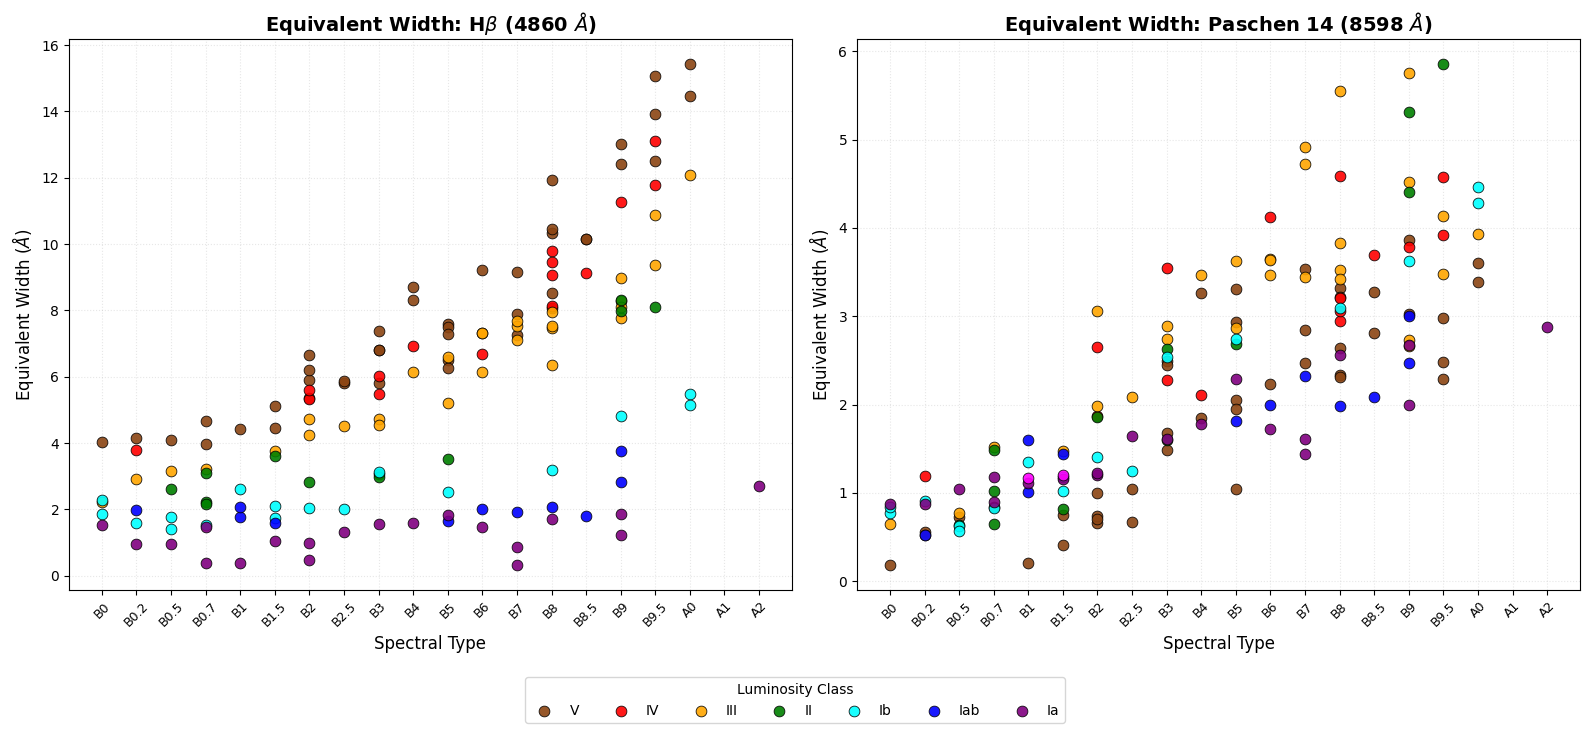

In [54]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# 1. Configuración de rutas
PATH_ANALISIS = r"C:\Users\User\Documents\TFG\Análisis"

# 2. Diccionario de estrellas
star_data_raw = {
    "HD37128": "B0 Ia", "HD205196": "B0 Ib", "HD164402": "B0 Ib", "HD48434": "B0 III",
    "HD149438": "B0 V", "HD171012": "B0.2 Ia", "HD204172": "B0.2 Iab", "HD16808": "B0.2 Ib",
    "HD6675": "B0.2 III", "HD36822": "B0.2 IV", "HD2083": "B0.2 V", "HD38771": "B0.5 Ia",
    "HD194839": "B0.5 Ia", "HD192422": "B0.5 Ib", "HD213087": "B0.5 Ib", "HD193007": "B0.5 II",
    "HD218376": "B0.5 III", "HD36960": "B0.5 V", "HD216411": "B0.7 Ia", "HD2905": "BC0.7 Ia",
    "HD190066": "B0.7 Ib", "HD190919": "B0.7 II", "HD193076": "B0.7 II", "HD14053": "B0.7 II",
    "HD13969": "B0.7 III", "HD37042": "B0.7 V", "HD201795": "B0.7 V", "HD169454": "B1 Ia+",
    "HD13256": "B1 Ia", "HD13854": "B1 Iab", "HD91316": "B1 Iab Ns", "HD24398": "B1 Ib",
    "HD44743": "B1 II–III", "HD144470": "B1 V", "HD24131": "B1 V", "HD190603": "B1.5 Ia+",
    "HD14956": "B1.5 Ia", "HD5551": "B1.5 Iab", "HD193183": "B1.5 Ib", "HD13841": "B1.5 Ib",
    "HD52089": "B1.5 II", "HD214993": "B1.5 III", "HD215191": "B1.5 V", "HD35299": "B1.5 V",
    "HD37744": "B1.5 V", "HD41117": "B2 Ia", "HD14143": "B2 Ia", "HD15690": "B2 Iab–Ib",
    "HD206165": "B2 Ib", "HD31327": "B2 II", "HD30836": "B2 III", "HD35468": "B2 III",
    "HD886": "B2 IV", "HD3360": "B2 IV", "HD36285": "B2 V", "HD36629": "B2 V",
    "HD144218": "B2 V", "HD208947": "B2 V", "HD198478": "B2.5 Ia", "HD42087": "B2.5 Ib",
    "HD207330": "B2.5 III", "HD148605": "B2.5 V", "HD175191": "B2.5 V", "HD14134": "B3 Ia",
    "HD53138": "B3 Ia", "HD51309": "B3 Ib", "HD36212": "B3 II", "HD194779": "B3 II",
    "HD21483": "B3 III", "HD49567": "B3 III", "HD3901": "B3 IV", "HD160762": "B3 IV",
    "HD20365": "B3 V", "HD32630": "B3 V", "HD120315": "B3 V", "HD178849": "B3 V",
    "HD36371": "B4 Ia", "HD164353": "B4 Ib–II", "HD41692": "B4 III", "HD180554": "B4 IV",
    "HD26739": "B4 V", "HD34759": "B4 V", "HD58350": "B5 Ia", "HD7902": "B5 Iab",
    "HD9311": "B5 Ib", "HD191243": "B5 II", "HD170682": "B5 III", "HD211924": "B5 III",
    "HD147394": "B5 V", "HD4142": "B5 V", "HD161572": "B5 V", "HD36936": "B5 V",
    "HD20809": "B5 V", "HD15497": "B6 Ia", "HD17145": "B6 Iab", "HD170719": "B6 III",
    "HD34503": "B6 III", "HD49340": "B6 III", "HD23338": "B6 IV", "HD90994": "B6 V",
    "HD183143": "B7 Ia", "HD199478": "B7 Ia", "HD208501": "B7 Iab", "HD35497": "B7 III",
    "HD23408": "B7 III", "HD1279": "B7 III", "HD23288": "B7 V", "HD21071": "B7 V",
    "HD182255": "B7 V", "HD34085": "B8 Ia", "HD14542": "B8 Iab", "HD12301": "B8 Ib",
    "HD23850": "B8 III", "HD155763": "B8 III", "HD179761": "B8 III", "HD10205": "B8 III",
    "HD17081": "B8 IV", "HD87901": "B8 IV", "HD3240": "B8 IV", "HD46075": "B8 IV",
    "HD23324": "B8 V", "HD23432": "B8 V", "HD21672": "B8 V", "HD171301": "B8 V",
    "HD224112": "B8 V", "HD184943": "B8.5 Iab", "HD214923": "B8.5 IV", "HD21279": "B8.5 V",
    "HD23923": "B8.5 V", "HD21291": "B9 Ia", "HD223960": "B9 Ia", "HD202850": "B9 Iab",
    "HD212593": "B9 Iab", "HD35600": "B9 Ib", "HD21661": "B9 II", "HD57608": "B9 II",
    "HD212097": "B9 III", "HD2011": "B9 III", "HD51688": "B9 III", "HD49606": "B9 III",
    "HD196867": "B9 IV", "HD21931": "B9 V", "HD38899": "B9 V", "HD176437": "B9.5 II",
    "HD181440": "B9.5 III", "HD144206": "B9.5 III", "HD186882": "B9.5 IV", "HD16046": "B9.5 IV",
    "HD23873": "B9.5 V", "HD23568": "B9.5 V", "HD222661": "B9.5 V", "HD21389": "A0 Ia",
    "HD46300": "A0 Ib", "HD87737": "A0 Ib", "HD123299": "A0 III", "HD103287": "A0 V",
    "HD172167": "A0 V", "HD197345": "A2 Ia"
}

star_data = {k.strip(): v for k, v in star_data_raw.items()}

# 3. Estética y Configuración
spectral_order = ["B0", "B0.2", "B0.5", "B0.7", "B1", "B1.5", "B2", "B2.5", "B3", "B4", "B5", "B6", "B7", "B8", "B8.5", "B9", "B9.5", "A0", "A1", "A2"]
spec_to_num = {spec: i for i, spec in enumerate(spectral_order)}
lum_colors = {"Ia+": "#FF00FF", "Ia": "#800080", "Iab": "#0000FF", "Ib": "#00FFFF", "II": "#008000", "III": "#FFA500", "IV": "#FF0000", "V": "#8B4513"}

# Identificadores de las líneas deseadas (basado en longitud de onda en el nombre del archivo)
target_lines = {
    "4860": r"H$\beta$ (4860 $\AA$)",
    "8598": r"Paschen 14 (8598 $\AA$)"
}

# 4. Procesamiento
files = [f for f in os.listdir(PATH_ANALISIS) if f.endswith('.csv')]
valid_files = []

# Filtrar solo los archivos que corresponden a Hbeta o Pa14
for f in files:
    for code in target_lines.keys():
        if code in f:
            valid_files.append((f, target_lines[code]))
            break

# Crear la figura (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for i, (file_name, line_title) in enumerate(valid_files[:2]): # Limitamos a los 2 encontrados
    file_path = os.path.join(PATH_ANALISIS, file_name)
    data_list = []
    
    with open(file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        for line in lines[1:]:
            parts = line.strip().split(',')
            if len(parts) >= 2:
                nombre_estrella = parts[0].strip().replace(' ', '')
                if nombre_estrella in star_data:
                    info = star_data[nombre_estrella] 
                    parts_info = info.split()
                    
                    data_list.append({
                        'X_Pos': spec_to_num.get(parts_info[0].replace('BC', 'B')),
                        'EW': float(parts[1]),
                        'Lum': parts_info[1] if len(parts_info) > 1 else "V"
                    })

    if data_list:
        df = pd.DataFrame(data_list)
        ax = axes[i]
        
        # Graficar por clase de luminosidad
        for lum in reversed(list(lum_colors.keys())):
            sub = df[df['Lum'] == lum]
            if not sub.empty:
                ax.scatter(sub['X_Pos'], sub['EW'], color=lum_colors[lum], 
                        edgecolors='black', s=60, alpha=0.9, linewidths=0.6, zorder=3, label=lum)
        
        ax.set_title(f"Equivalent Width: {line_title}", fontweight='bold', fontsize=14)
        ax.set_xticks(range(len(spectral_order)))
        ax.set_xticklabels(spectral_order, rotation=45, fontsize=9)
        ax.set_ylabel("Equivalent Width ($\AA$)", fontsize=12)
        ax.set_xlabel("Spectral Type", fontsize=12)
        ax.grid(alpha=0.3, linestyle=':')

# 5. Leyenda unificada
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Luminosity Class", loc='lower center', 
        ncol=8, bbox_to_anchor=(0.5, -0.05), frameon=True, fontsize=10)

plt.tight_layout()
plt.subplots_adjust(bottom=0.15) # Espacio para la leyenda
plt.show()